# Floe size tendencies

Recreate and compare with [Roach et al. (JGR: Oceans, 2018)](https://doi.org/10.1029/2017JC013692) and [Roach et al. (JAMES, 2019)](https://doi.org/10.1029/2019MS001836) floe-size distribution diagnostics with an ACCESS-OM3 simulation selected by `esm_file`.

Roach et al. (2018) uses standalone CICE5.1 with a slab ocean model and the floe size thickness distribution (FSTD) implemented. A simple wave forcing is applied, where waves propagate along meridonal lines. All new floes are created in the smallest floe size category. 

Roach et al. (2019) used five experiments:
| Experiment name | Model components | Run period | Initialization |
|---|---|---:|---|
| FSDv1-NEMO | NEMO, Wavewatch hindcast | 1976-2014 | Equivalent climatological run<sup>a</sup> |
| FSDv1 | SOM, Wavewatch hindcast | 1976-2014 | Equivalent climatological run |
| FSDv2 | SOM, Wavewatch hindcast | 1976-2014 | Equivalent climatological run |
| NOFSD | SOM | 1976-2014 | Equivalent climatological run |
| FSDv2-WAVE | SOM, coupled Wavewatch | 2000-2014 | FSDv2 at year 2000 |

*Note.* Climatological runs use repeat-1975 atmospheric forcing. SOM = slab ocean model.  
<sup>a</sup>As presented in Roach et al. (2018).

FSDv2 introduced wave-dependent new ice formation and FSDv2-WAVE is the most comparable to ACCESS-OM3-MCW.


References:
- Roach, L. A., Horvat, C., Dean, S. M., & Bitz, C. M. (2018). An emergent sea ice floe size distribution in a global coupled ocean-sea ice model. *Journal of Geophysical Research: Oceans*, 123, 4322–4337. https://doi.org/10.1029/2017JC013692

- Roach, L. A., Bitz, C. M., Horvat, C., & Dean, S. M. (2019). Advances in modeling interactions between sea ice and ocean surface waves. *Journal of Advances in Modeling Earth Systems*, 11, 4167–4181. https://doi.org/10.1029/2019MS001836

- Rothrock, D. A., and A. S. Thorndike (1984), Measuring the sea ice floe size distribution, *J. Geophys. Res.*, 89(C4), 6477–6486, https://doi.org/10.1029/JC089iC04p06477.


**TODO**
- Regridding?
- dafsd unit conversion for Roach2019
- Horvat 2021?
- pcolormesh -> contourf?

In [51]:
from pathlib import Path
# These first two cells must be in all notebooks!
# It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in
# arguments externally using papermill (see mkfigs.sh for details)

# Set esm_file to the datastore for the main experiment of interest.
esm_file = "/scratch/ps29/nd0349/access-om3/archive/IC4M8-MCW-100km_jra_iaf_2010/experiment_datastore.json"
# constant_esm_file = "/g/data/ps29/nd0349/access-om3/configurations/mcw/IC4M8-MCW-100km_jra_iaf_2010-constant/archive/experiment_datastore.json"
baseline_esm_file = "/g/data/ps29/nd0349/access-om3/configurations/mcw/IC4M8-MCW-100km_jra_iaf_2010-nofrac/archive/experiment_datastore.json"

roach_data_dir = "/g/data/ps29/nd0349/ia40/roach_studies/roach_2019"
roach_2018_data_dir = "/g/data/ps29/nd0349/ia40/roach_studies/roach_2018"
analysis_functions_dir = "/g/data/ps29/nd0349/access-om3-analysis/functions"

roach_cases = {
    "FSDv1": "cice_FSDv1_LR_2000-2014.nc",
    "FSDv2": "cice_FSDv2_LR_2000-2014.nc",
}
wave_file = "ww3_sigheight_FSDv2-WAVE_LR_2000-2014.nc"

# User settings.
start_year = 2000
end_year = 2014
min_ice_area_fraction = 0.15
REGRID_ROACH_DATASETS = False # Todo: True not working
regrid_method = "bilinear"
regrid_periodic = True
overwrite_regridded_roach = False

# Figure styling and limits.
def experiment_name_from_esm_file(esm_file):
    path = Path(esm_file)

    if path.name == "experiment_datastore.json" and path.parent.name == "archive":
        return path.parent.parent.name

    return path.parent.name
OM3_LABEL = experiment_name_from_esm_file(esm_file)
# CONSTANT_LABEL = experiment_name_from_esm_file(constant_esm_file)
BASELINE_LABEL = experiment_name_from_esm_file(baseline_esm_file)
print(f"ACCESS OM3 experiment: {OM3_LABEL}")
print(f"ACCESS OM3 baseline: {BASELINE_LABEL}")
PERIMETER_LIMITS = (0, 700)
REP_RADIUS_LIMITS = (0, 600)
TENDENCY_SCALE = 1.0
FLOE_SHAPE = 0.66
NOFSD_PERIMETER_KM = 15.9
NOFSD_FSDRAD = 300.0

TENDENCY_LABELS = {
    "dafsd_newi": "New ice",
    "dafsd_latg": "Lateral growth",
    "dafsd_latm": "Lateral melt",
    "dafsd_weld": "Welding",
    "dafsd_wave": "Wave fracture",
}

tendency_candidates = list(TENDENCY_LABELS)

# papermill settings. *No need to modify these if running interactively.*
papermill = False
cwd = None
nbname = None

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-om3-paper-figs/"
os.makedirs(plotfolder, exist_ok=True)
print(f"Plot folder: {plotfolder}")

ACCESS OM3 experiment: IC4M8-MCW-100km_jra_iaf_2010
ACCESS OM3 baseline: IC4M8-MCW-100km_jra_iaf_2010-nofrac
Plot folder: /g/data/ps29/nd0349/access-om3-paper-figs/


In [2]:
if not papermill:
    import os
    try:
        import nci_ipynb
        cwd = nci_ipynb.dir()
        nbname = nci_ipynb.name()
    except FileNotFoundError:
        cwd = Path("/g/data/ps29/nd0349/access-om3-paper-1/notebooks")
        nbname = "FloeSizeTendencies.ipynb"
    os.chdir(cwd)
from mkfigs_configdoc import MkmdWriter
mkmd = MkmdWriter(esm_file, nbname, str(cwd), pm=papermill)


In [3]:
import sys
import warnings
import textwrap

import intake
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import xarray as xr

try:
    import xesmf as xe
    HAS_XESMF = True
except ImportError:
    xe = None
    HAS_XESMF = False
from distributed import Client

warnings.filterwarnings("ignore")

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cft
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False

try:
    import cmocean
    BALANCE_CMAP = cmocean.cm.balance
    BALANCE_CMAP_R = cmocean.cm.balance_r
    ICE_CMAP = cmocean.cm.ice
except ImportError:
    BALANCE_CMAP = "RdBu_r"
    BALANCE_CMAP_R = "RdBu"
    ICE_CMAP = "Blues"

hemisphere_limits = {'north': [-180, 180, 50, 90],
                     'south': [-180, 180, -50, -90],
}


In [4]:
client = Client(threads_per_worker=1)
client


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46045,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:32935,Total threads: 1
Dashboard: /proxy/41351/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:44991,


2026-07-16 14:00:36,136 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('and_-ddb6a1849c3dbe1598aec7ff297e8b1d', 0, 0) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: <Task ('and_-ddb6a1849c3dbe1598aec7ff297e8b1d', 0, 0) _execute_subgraph(...)>
new run_spec: <Task ('and_-ddb6a1849c3dbe1598aec7ff297e8b1d', 0, 0) _execute_subgraph(...)>
old dependencies: {('rechunk-merge-cd3ddb3990d27d45daa5a4af98e22a3c', 0, 0), ('sub-bbf4ad572ee476e552ce5288ea46ca36', 0, 0)}
new dependencies: frozenset({('rechunk-merge-cd3ddb3990d27d45daa5a4af98e22a3c', 0, 0), ('rechunk-merge-83e9ef25e352006c70aa38db8cd39dd1', 0, 0

In [5]:
print(client.dashboard_link)

/proxy/8787/status


## Open MCW and Roach 2018 data


In [6]:
# ACCESS-OM3 datasets
COLUMNS_WITH_ITERABLES = [
    "variable",
    "variable_long_name",
    "variable_standard_name",
    "variable_cell_methods",
    "variable_units",
]

baseline_datastore = intake.open_esm_datastore(baseline_esm_file, columns_with_iterables=COLUMNS_WITH_ITERABLES)
# constant_datastore = intake.open_esm_datastore(constant_esm_file, columns_with_iterables=COLUMNS_WITH_ITERABLES)
datastore = intake.open_esm_datastore(esm_file, columns_with_iterables=COLUMNS_WITH_ITERABLES)

# Roach et al. (2018) datasets
roach_dir = Path(roach_data_dir)
roach = {name: xr.open_dataset(roach_dir / filename, chunks={"time": "auto"}) for name, filename in roach_cases.items()}
wave = xr.open_dataset(roach_dir / wave_file, chunks={"time": "auto"})
roach


{'FSDv1': <xarray.Dataset> Size: 1GB
 Dimensions:    (nj: 384, ni: 320, time: 180, nkfsd: 12)
 Coordinates:
     TLON       (nj, ni) float32 492kB dask.array<chunksize=(384, 320), meta=np.ndarray>
     ULON       (nj, ni) float32 492kB dask.array<chunksize=(384, 320), meta=np.ndarray>
     TLAT       (nj, ni) float32 492kB dask.array<chunksize=(384, 320), meta=np.ndarray>
     ULAT       (nj, ni) float32 492kB dask.array<chunksize=(384, 320), meta=np.ndarray>
   * time       (time) object 1kB 2000-01-01 00:00:00 ... 2014-12-01 00:00:00
     NFSD       (nkfsd) float64 96B dask.array<chunksize=(12,), meta=np.ndarray>
 Dimensions without coordinates: nj, ni, nkfsd
 Data variables:
     tarea      (nj, ni) float32 492kB dask.array<chunksize=(384, 320), meta=np.ndarray>
     aice       (time, nj, ni) float32 88MB dask.array<chunksize=(180, 384, 320), meta=np.ndarray>
     meltl      (time, nj, ni) float32 88MB dask.array<chunksize=(180, 384, 320), meta=np.ndarray>
     meltb      (time, nj,

In [7]:

def filter_existing_files(query):
    if query is None or len(query.df) == 0:
        return None

    if "path" not in query.df:
        return query

    existing = query.df["path"].astype(str).map(lambda p: Path(p).exists())
    paths = query.df.loc[existing, "path"].tolist()

    if not paths:
        return None

    return query.search(path=paths)


def open_access_om3_cice_dataset(datastore, monthly_from_daily=True):
    available = set(available_variables(datastore).index.astype(str))

    monthly_variables = [
        v for v in access_om3_variable_candidates
        if (v.endswith("_m") or v in {"meltl", "meltb"}) and v in available
    ]

    daily_variables = [
        v for v in access_om3_variable_candidates
        if not v.endswith("_m") and v in available
    ]

    query_1mon = None
    query_1day = None

    if monthly_variables:
        query_1mon = datastore.search(frequency="1mon", variable=monthly_variables)
        query_1mon = filter_existing_files(query_1mon)

    if daily_variables:
        query_1day = datastore.search(frequency="1day", variable=daily_variables)
        query_1day = filter_existing_files(query_1day)

    using_daily = False

    if query_1mon is not None and len(query_1mon.df) > 0:
        query = query_1mon
    elif monthly_from_daily and query_1day is not None and len(query_1day.df) > 0:
        query = query_1day
        using_daily = True
    else:
        raise ValueError(
            "No usable ACCESS-OM3 CICE/FSD 1mon or 1day files found in datastore.\n"
            f"monthly_variables={monthly_variables}\n"
            f"daily_variables={daily_variables}\n"
            f"frequencies={sorted(datastore.df['frequency'].dropna().unique())}"
        )

    ds = query.to_dask(
        xarray_combine_by_coords_kwargs={
            "compat": "override",
            "data_vars": "minimal",
            "coords": "minimal",
        },
        xarray_open_kwargs={"chunks": {}, "decode_timedelta": True},
    )

    if "time" in ds:
        ds["time"] = ds.time.to_pandas()

    if using_daily:
        ds = ds.resample(time="MS").mean(keep_attrs=True)

    ds = rename_to_om3_convention(ds)

    # keep your static grid + thickness code here

    static = datastore.search(file_id="access_om3_cice_static")
    if len(static.df) == 0:
        static = datastore.search(filename="access-om3.cice.static.nc")

    if len(static.df) > 0:
        grid_ds = xr.open_dataset(static.df["path"].iloc[0], chunks={})
        for coord in ["TLON", "TLAT", "ULON", "ULAT", "NLON", "NLAT", "ELON", "ELAT", "NCAT", "NFSD"]:
            if coord in grid_ds and coord not in ds:
                ds = ds.assign_coords({coord: grid_ds[coord].fillna(0) if coord != "NFSD" else grid_ds[coord]})
        for var in ["tarea", "uarea", "tmask"]:
            if var in grid_ds and var not in ds:
                ds[var] = grid_ds[var]

    if "hi" in ds and "aice" in ds:
        ds["thickness"] = ds["hi"] / ds["aice"].where(ds["aice"] > 1.0e-12)
        ds["thickness"].attrs["long_name"] = "Effective ice thickness"
        ds["thickness"].attrs["description"] = "Computed as hi / aice"
        ds["thickness"].attrs["units"] = "m"


    return ds
    
def available_variables(datastore):
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

def rename_to_om3_convention(ds):
    renames = {old: new for old, new in OM3_NAME_RENAMES.items() if old in ds and new not in ds}
    return ds.rename(renames) if renames else ds

In [8]:
# LOAD ACCESS-OM3 CICE data

model = "access-om3"

access_om3_variable_candidates = [
    "aice", "aice_m",
    "hi", "hi_m",
    "areal_fsd", "afsd", "afsd_m",
    "dafsdani", "dafsdani_m",
    "dafsdlatg", "dafsdlatg_m",
    "dafsdlatm", "dafsdlatm_m",
    "dafsdmrg", "dafsdmrg_m",
    "dafsdwave", "dafsdwave_m",
    "dafsd_newi", "dafsd_latg", "dafsd_latm", "dafsd_weld", "dafsd_wave",
    "fsdrad", "fsdperim",
    "meltl", "meltb",
]

OM3_NAME_RENAMES = {
    "aice_m": "aice",
    "hi_m": "hi",
    "meltt_m": "meltt",
    "meltl_m": "meltl",
    "meltb_m": "meltb",
    "wave_sig_ht_m": "wave_sig_ht",
    "fsdrad_m": "fsdrad",
    "fsdperim_m": "fsdperim",
    "areal_fsd": "afsd",
    "areal_fsd_m": "afsd",
    "afsd_m": "afsd",
    "dafsdani": "dafsd_newi",
    "dafsdani_m": "dafsd_newi",
    "dafsd_newi_m": "dafsd_newi",
    "dafsdlatg": "dafsd_latg",
    "dafsdlatg_m": "dafsd_latg",
    "dafsd_latg_m": "dafsd_latg",
    "dafsdlatm": "dafsd_latm",
    "dafsdlatm_m": "dafsd_latm",
    "dafsd_latm_m": "dafsd_latm",
    "dafsdmrg": "dafsd_weld",
    "dafsdmrg_m": "dafsd_weld",
    "dafsd_weld_m": "dafsd_weld",
    "dafsdwave": "dafsd_wave",
    "dafsdwave_m": "dafsd_wave",
    "dafsd_wave_m": "dafsd_wave",
}

om3_datasets = {
    BASELINE_LABEL: open_access_om3_cice_dataset(baseline_datastore, monthly_from_daily=True),
    # CONSTANT_LABEL: open_access_om3_cice_dataset(constant_datastore, monthly_from_daily=True),
    OM3_LABEL: open_access_om3_cice_dataset(datastore),
}
om3_datasets

{'IC4M8-MCW-100km_jra_iaf_2010-nofrac': <xarray.Dataset> Size: 20GB
 Dimensions:      (time: 150, nj: 300, ni: 360, nf: 12, nc: 5, nkice: 4,
                   nksnow: 1, nkbio: 3, nkaer: 5)
 Coordinates:
   * time         (time) datetime64[ns] 1kB 2010-01-01 2010-02-01 ... 2022-06-01
     TLON         (nj, ni) float64 864kB dask.array<chunksize=(150, 180), meta=np.ndarray>
     TLAT         (nj, ni) float64 864kB dask.array<chunksize=(150, 180), meta=np.ndarray>
     ULON         (nj, ni) float64 864kB dask.array<chunksize=(150, 180), meta=np.ndarray>
     ULAT         (nj, ni) float64 864kB dask.array<chunksize=(150, 180), meta=np.ndarray>
     NLON         (nj, ni) float64 864kB dask.array<chunksize=(150, 180), meta=np.ndarray>
     NLAT         (nj, ni) float64 864kB dask.array<chunksize=(150, 180), meta=np.ndarray>
     ELON         (nj, ni) float64 864kB dask.array<chunksize=(150, 180), meta=np.ndarray>
     ELAT         (nj, ni) float64 864kB dask.array<chunksize=(150, 180), met

## Add floe size distribution diagnostics


### ACCESS-OM3 native FSD diagnostic checks

Use the OM3-native `fsdrad` and `fsdperim` diagnostics as test cases for the calculated representative radius and floe perimeter per unit ice area.


In [9]:
# Temporal average helpers
def monthly_mean(da, month):
    return mean_over_time_month(da, month=month)
    
def mean_over_time_month(da, month=None, years=None):
    if "time" not in da.dims:
        return da
    out = da
    if years is not None:
        out = out.sel(time=slice(f"{years[0]}-01-01", f"{years[1]}-12-31"))
    if month is not None:
        out = out.where(out["time"].dt.month == month, drop=True)
    return out.mean("time", skipna=True)

# Spatial average helpers
def subset_named_hemisphere(da, ds, hemi):
    lat_name, _ = lat_lon_names(ds)
    if lat_name is None:
        return da
    lat = ds[lat_name]
    if hemi.lower().startswith("north"):
        return da.where(lat >= 0)
    if hemi.lower().startswith("south"):
        return da.where(lat <= 0)
    return da

def lat_lon_names(ds):
    lat = coord_name(ds, ["geolat_t", "TLAT", "tlat", "lat", "latitude", "yt_ocean", "nj"])
    lon = coord_name(ds, ["geolon_t", "TLON", "tlon", "lon", "longitude", "xt_ocean", "ni"])
    return lat, lon

def coord_name(ds, names):
    for name in names:
        if name in ds.coords or name in ds.data_vars or name in ds.dims:
            return name
    return None

# Seasonality helpers
def hemi_weighted_mean(da, ds, hemi):
    da = subset_named_hemisphere(da, ds, hemi)
    spatial_dims = spatial_dims_for(da)
    if not spatial_dims:
        return da
    weight = area_weight(ds)
    if weight is None:
        return da.mean(spatial_dims, skipna=True)
    weight = subset_named_hemisphere(weight, ds, hemi)
    da, weight = xr.align(da, weight, join="inner")
    return da.weighted(weight.where(np.isfinite(da)).fillna(0)).mean(spatial_dims)

def spatial_dims_for(da):
    return [dim for dim in da.dims if dim not in ["time", "month", "nf", "floe_radius"]]

def fsd_tendency_cycle_hemi(ds, var, hemi):
    ts = seasonal_cycle(integrate_afsd_tendency(ds, var, hemi=None), ds, hemi)
    ts.name = TENDENCY_LABELS.get(var)
    ts.attrs["units"] = "m/day"
    return ts

def area_weight(ds):
    area_name = coord_name(ds, ["area_t", "tarea", "area"])
    if area_name is not None:
        return ds[area_name]
    lat_name, _ = lat_lon_names(ds)
    if lat_name is not None:
        return np.cos(np.deg2rad(ds[lat_name])).clip(min=0.0)
    return None

def seasonal_cycle(ds, var):
    da = integrate_radius_tendency(ds, var)
    da = subset_hemisphere(da, ds)
    weight = area_weight(ds).fillna(0)
    spatial_dims = [dim for dim in da.dims if dim != "time"]
    if weight is not None and spatial_dims:
        da, weight = xr.align(da, weight, join="inner")
        ts = da.weighted(weight.where(np.isfinite(da)).fillna(0)).mean(spatial_dims)
    else:
        ts = da.mean(spatial_dims)
    return ts.groupby("time.month").mean("time").load()

def subset_hemisphere(da, ds):
    lat_name, _ = lat_lon_names(ds)
    if lat_name is None:
        return da
    lat = ds[lat_name]
    if hemisphere.lower().startswith("north"):
        return da.where(lat >= 0)
    if hemisphere.lower().startswith("south"):
        return da.where(lat <= 0)
    return da

### Number FSD, representative radius and perimeter calculations
The areal FSD, $f(r)$, can be related to the number FSD by Eq. (10) of [Roach et al. (2018)](https://doi.org/10.1029/2017JC013692)
$$ f^N(r) = \frac{f(r)}{4\,\alpha\,r^2} $$
where $\alpha=0.66$ is the noncircularity of floes [Rothrock and Thorndike (1984)](https://doi.org/10.1029/JC089iC04p06477).

The representenative radius, $r_a$, is the first moment of the $f(r)$ normalised by the areal ice fraction
$$ r_a = \frac{\langle r^1 \rangle}{\langle r^0 \rangle} = \frac{\int_{\mathcal{R}} r\,f(r)\,\mathrm{d}r}{\int_{\mathcal{R}} f(r)\, \mathrm{d}r} = \frac{1}{a_i}\int_{\mathcal{R}} r\,f(r)\,\mathrm{d}r$$
see Eq. (26) from [Roach et al. (2018)](https://doi.org/10.1029/2017JC013692).

The perimeter of floes per unit area of sea ice, $P_i$, is defined as
$$ P_i = 2\frac{\langle r^{-1} \rangle}{\langle r^{0} \rangle}, $$
in Eq. (11) of [Roach et al. (2019)](https://doi.org/10.1029/2019MS001836).

In [10]:
def floe_area_from_radius(radius, floe_shape=FLOE_SHAPE):
    return 4.0 * floe_shape * radius**2
    
def number_fsd(ds, area_unit="m", write_to_ds=True):
    out = ds["nfsd"] = ds["afsd"] / floe_area_from_radius(ds["NFSD"])
    if area_unit == "km":
        out = out * 1e6
    elif area_unit != "m":
        raise ValueError("area_unit must be 'm' or 'km'")
    
    out.name = "nfsd"
    out.attrs["long_name"] = "Number floe size distribution"
    out.attrs["units"] = f"{area_unit}-2"
    if write_to_ds:
        ds[out.name] = out
        return ds
    else:
        return out
    

def number_fsd_tendency(ds, var, time_unit="h", area_unit="m", write_to_ds=True):
    out = ds[var] / floe_area_from_radius(ds["NFSD"])

    if time_unit == "d":
        out = out * 24.0
    elif time_unit != "h":
        raise ValueError("time_unit must be 'h' or 'd'")

    if area_unit == "km":
        out = out * 1e6
    elif area_unit != "m":
        raise ValueError("area_unit must be 'm' or 'km'")

    out.name = f"{var}_n"
    out.attrs["long_name"] = "Number floe size distribution tendency"
    out.attrs["units"] = f"{area_unit}-2 {time_unit}-1"

    if write_to_ds:
        ds[out.name] = out
        return ds
    else:
        return out
    
    
def representative_radius(ds, use_native=False, threshold=0.15, write_to_ds=True):
    threshold = min_ice_area_fraction if threshold is None else threshold
    if use_native and "fsdrad" in ds:
        out = ds["fsdrad"]
        return out
    dim = ds["NFSD"].dims[0]
    aice_name = var_if_present(ds, ["aice", "aice_m"])
    if aice_name is None:
        return None
    aice = ds[aice_name]
    valid = aice > threshold
    aice = aice.where(valid)

    dim = ds["NFSD"].dims[0]
    name = fsd_area_var(ds)

    if name is None:
        template_name = var_if_present(ds, ["aice", "hi"])
        if template_name is None:
            return None

        value = NOFSD_FSDRAD

        out = xr.ones_like(ds[template_name]) * value
        out.name = "fsdrad"
        out.attrs["long_name"] = "Representative floe radius"
        out.attrs["units"] = "m"

        if write_to_ds:
            ds[out.name] = out
            return ds
        return out
        
    mom_1 = calculate_moment(ds, ds['afsd'], 1, threshold=threshold).where(valid)
    mom_0 = aice # calculate_moment(ds, ds['afsd'], 0, threshold=threshold).where(valid)
    out = ( mom_1 / mom_0.where(valid) ).sum(dim, skipna=True).where(valid)
    out = out.where(valid, other=0.0)
    out.name = "fsdrad"
    out.attrs["long_name"] = "Representative floe radius"
    out.attrs["units"] = "m"
    if write_to_ds:
        ds[out.name] = out
        return ds
    else:
        return out


def perimeter_per_ice_area(ds, use_native=False, threshold=0.15, length_unit="m", write_to_ds=True):
    threshold = min_ice_area_fraction if threshold is None else threshold

    if length_unit not in ["m", "km"]:
        raise ValueError("length_unit must be 'm' or 'km'")

    if use_native and "fsdperim" in ds:
        out = ds["fsdperim"].copy()
        units = str(out.attrs.get("units", "")).lower().replace(" ", "")

        # Convert native value to requested output units.
        if length_unit == "km" and units in ["", "m-1", "m^-1", "1/m", "m**-1"]:
            out = out * 1000.0
        elif length_unit == "m" and units in ["km-1", "km^-1", "1/km", "km**-1"]:
            out = out / 1000.0

        out.name = "perimeter_per_ice_area"
        out.attrs["long_name"] = "Floe perimeter per unit ice area"
        out.attrs["units"] = f"{length_unit}-1"

        if write_to_ds:
            ds[out.name] = out
            return ds
        return out

    dim = ds["NFSD"].dims[0]
    name = fsd_area_var(ds)

    if name is None:
        template_name = var_if_present(ds, ["aice", "hi"])
        if template_name is None:
            return None

        value = NOFSD_PERIMETER_KM if length_unit == "km" else NOFSD_PERIMETER_KM / 1000.0

        out = xr.ones_like(ds[template_name]) * value
        out.name = "fsdperim"
        out.attrs["long_name"] = "Floe perimeter per unit ice area"
        out.attrs["units"] = f"{length_unit}-1"

        if write_to_ds:
            ds[out.name] = out
            return ds
        return out

    aice_name = var_if_present(ds, ["aice", "aice_m"])
    if aice_name is None:
        return None

    aice = ds[aice_name]
    valid = aice > threshold

    mom_m1 = calculate_moment(ds, ds['afsd'], -1, threshold=threshold).where(valid)

    out = 2.0 * (mom_m1 / aice.where(valid)).sum(dim, skipna=True)

    # Base result is m^-1. Convert to km^-1 if requested.
    if length_unit == "km":
        out = out * 1000.0

    out = out.where(valid)
    out.name = "fsdperim"
    out.attrs["long_name"] = "Floe perimeter per unit ice area"
    out.attrs["units"] = f"{length_unit}-1"

    if write_to_ds:
        ds[out.name] = out
        return ds
    return out


def integrate_radius_tendency(ds, var, threshold=0.15, input_time_unit="h", output_time_unit="d", write_to_ds=True):
    dim = ds["NFSD"].dims[0]
    valid = ds["aice"] > threshold
    mom_1 = calculate_moment(ds, ds[var], 1, threshold=threshold).where(valid)

    aice_name = var_if_present(ds, ["aice", "aice_m"])
    if aice_name is None:
        raise ValueError("Need aice/aice_m to compute radius-weighted FSD tendency.")
    aice = ds[aice_name].where(ds[aice_name] > threshold)
    out = mom_1.sum(dim, skipna=True) / aice

    if input_time_unit == output_time_unit:
        factor = 1.0
    elif input_time_unit == "h" and output_time_unit == "d":
        factor = 24.0
    elif input_time_unit == "d" and output_time_unit == "h":
        factor = 1.0 / 24.0
    elif input_time_unit == "m" and output_time_unit == "d":
        factor = 1.0 / 12.0
    else:
        raise ValueError("Supported time units are 'h' and 'd'.")

    out = out * factor

    out.name = f"{var}_ra"
    out.attrs["long_name"] = f"{TENDENCY_LABELS.get(var, var)} tendency"
    out.attrs["units"] = f"m {output_time_unit}-1"

    if write_to_ds:
        ds[out.name] = out
        return ds

    return out

FSD helpers

In [11]:

def fsd_binwidths(NFSD, min_floe = 6.65000000e-02):
    """
    Return the bin widths used in for the FSD.
    """
    # Define arrays
    fsd_lims   = np.zeros(len(NFSD)+1)
    floe_rad_c = np.zeros(len(NFSD))
    floe_rad_l = np.zeros(len(NFSD))
    floe_rad_h = np.zeros(len(NFSD))
    
    fsd_lims[1] = min_floe;
    for i in range(len(NFSD)):
        fsd_lims[i+1] = 2*NFSD[i] - fsd_lims[i]
        floe_rad_c[i] = NFSD[i]
    
    floe_rad_l = fsd_lims[0:-1]
    floe_rad_h = fsd_lims[1:]
    floe_binwidth = floe_rad_h - floe_rad_l
    
    floe_area_l = 4*FLOE_SHAPE*floe_rad_l**2
    floe_area_c = 4*FLOE_SHAPE*floe_rad_c**2
    floe_area_h = 4*FLOE_SHAPE*floe_rad_h**2
    
    bin_width = floe_rad_h - floe_rad_l
    bin_left = floe_rad_l
    bin_right = floe_rad_h
    
    return bin_width, bin_left, bin_right

def fsd_binwidths_xr(NFSD):
    """
    Return CICE floe-size bin widths/edges as xarray DataArrays.
    NFSD can be an xr.DataArray or a numpy array.
    """
    if isinstance(NFSD, xr.DataArray):
        nf_dim = NFSD.dims[0]
        nf_coord = NFSD
        values = NFSD.values
    else:
        nf_dim = "nf"
        values = np.asarray(NFSD)
        nf_coord = xr.DataArray(values, dims=nf_dim, name="NFSD", attrs={"units": "m"})

    widths, left, right = fsd_binwidths(values)

    bin_width = xr.DataArray(
        widths,
        dims=nf_dim,
        coords={nf_dim: nf_coord},
        name="floe_binwidth",
        attrs={"units": "m", "long_name": "floe-size bin width"},
    )

    bin_left = xr.DataArray(
        left,
        dims=nf_dim,
        coords={nf_dim: nf_coord},
        name="floe_bin_left",
        attrs={"units": "m", "long_name": "left edge of floe-size bin"},
    )

    bin_right = xr.DataArray(
        right,
        dims=nf_dim,
        coords={nf_dim: nf_coord},
        name="floe_bin_right",
        attrs={"units": "m", "long_name": "right edge of floe-size bin"},
    )

    return bin_width, bin_left, bin_right

def calculate_moment(ds, da, moment_no, threshold=0.15):
    width = fsd_binwidths_xr(ds["NFSD"])[0]
    radii = ds["NFSD"]
    dim = ds["NFSD"].dims[0]
    if dim is None:
        return None
    mom = radii**moment_no * da * width
    return mom

def fsd_area_var(ds):
    return var_if_present(ds, ["afsd", "areal_fsd"])

def fsd_is_density(ds):
    return bool(ds.attrs.get("fsd_is_density", False))

def var_if_present(ds, candidates):
    for name in candidates:
        if name in ds:
            return name
    return None

Validate that the calculation of representative radii and perimeters is correct

In [12]:
# Test calculated FSD diagnostics against native OM3 fsdrad/fsdperim.
def _name(ds, candidates):
    for name in candidates:
        if name in ds:
            return name
    return None

def _om3_fsd_dim(ds, da):
    if "NFSD" in ds:
        n = ds["NFSD"].size
        for dim in da.dims:
            if da.sizes[dim] == n:
                return dim

    for dim in da.dims:
        if dim.lower() in ["nf", "nfsd", "floe_radius"]:
            return dim
    return None

def _om3_fsd_radii(ds, da):
    dim = _om3_fsd_dim(ds, da)
    if dim is None:
        raise ValueError(f"Could not identify floe-size dimension in {da.dims}.")

    if "NFSD" not in ds:
        raise ValueError("Need ds['NFSD'] from the CICE static file.")

    return dim, xr.DataArray(
        np.asarray(ds["NFSD"].values, dtype=float),
        dims=dim,
        coords={dim: da[dim]},
        name="NFSD",
        attrs={"units": "m"},
    )

def maybe_time_sample(da, time_step=1):
    if "time" in da.dims and time_step > 1:
        return da.isel(time=slice(None, None, time_step))
    return da


def fsd_diagnostic_error_metrics(calc, ref, ds=None, aice_threshold=0.15, time_step=1):
    calc = maybe_time_sample(calc, time_step)
    ref = maybe_time_sample(ref, time_step)
    calc, ref = xr.align(calc, ref, join="inner")

    valid = np.isfinite(calc) & np.isfinite(ref)

    if ds is not None:
        aice_name = _name(ds, ["aice", "aice_m"])
        if aice_name is not None:
            aice = maybe_time_sample(ds[aice_name], time_step)
            calc, ref, aice = xr.align(calc, ref, aice, join="inner")
            valid = valid & (aice > aice_threshold)

    diff = (calc - ref).where(valid)

    return xr.Dataset({
        "mean_calc": calc.where(valid).mean(),
        "mean_ref": ref.where(valid).mean(),
        "bias": diff.mean(),
        "mean_abs_error": np.abs(diff).mean(),
        "rmse": np.sqrt((diff ** 2).mean()),
        "max_abs_error": np.abs(diff).max(),
    })


def check_fsd_diagnostics(ds, time_step="auto", aice_threshold=0.15):
    if time_step == "auto":
        time_step = max(1, ds.sizes.get("time", 1) // 240)

    checks = []

    missing = {
        "afsd": _name(ds, ["afsd", "afsd_m", "areal_fsd", "areal_fsd_m"]) is None,
        "NFSD": "NFSD" not in ds,
        "aice": _name(ds, ["aice", "aice_m"]) is None,
        "fsdrad/fsdperim": (
            _name(ds, ["fsdrad", "fsdrad_m"]) is None
            and _name(ds, ["fsdperim", "fsdperim_m"]) is None
        ),
    }

    if any(missing.values()):
        return pd.DataFrame({
            "missing": [", ".join(k for k, v in missing.items() if v)],
            "available_fsd_vars": [
                ", ".join(v for v in ds.data_vars if "fsd" in v.lower() or "afsd" in v.lower())
            ],
            "available_coords": [", ".join(ds.coords)],
        })

    calc_radius = representative_radius(ds, use_native=False, write_to_ds=False)
    native_radius = representative_radius(ds, use_native=True, write_to_ds=False)
    if calc_radius is not None and native_radius is not None:
        checks.append(
            fsd_diagnostic_error_metrics(
                calc_radius,
                native_radius,
                ds,
                aice_threshold=aice_threshold,
                time_step=time_step,
            ).assign_coords(diagnostic="representative radius")
        )

    calc_perim = perimeter_per_ice_area(ds, length_unit="km", use_native=False, write_to_ds=False)
    native_perim = perimeter_per_ice_area(ds, length_unit="km", use_native=True, write_to_ds=False)
    if calc_perim is not None and native_perim is not None:
        checks.append(
            fsd_diagnostic_error_metrics(
                calc_perim,
                native_perim,
                ds,
                aice_threshold=aice_threshold,
                time_step=time_step,
            ).assign_coords(diagnostic="perimeter per ice area")
        )

    return xr.concat(checks, dim="diagnostic").compute().to_dataframe()


ds_om3_fsd_diagnostic_table = check_fsd_diagnostics(om3_datasets[OM3_LABEL].isel(time=0))
ds_om3_fsd_diagnostic_table

,mean_calc,mean_ref,bias,mean_abs_error,rmse,max_abs_error,time
diagnostic,,,,,,,
representative radius,202.767013,201.384744,1.382269,1.813850,4.957022,53.600073,2010-01-16 12:00:00
perimeter per ice area,455.538552,445.045744,10.492808,16.195746,37.344881,499.695991,2010-01-16 12:00:00


In [47]:
for case, ds_om3 in om3_datasets.items():
    if "nfsd" not in ds_om3 and "afsd" in ds_om3:
        ds_om3 = number_fsd(ds_om3, area_unit="km")

    if "fsdrad" not in ds_om3:
        ds_om3 = representative_radius(ds_om3)

    if "fsdperim" not in ds_om3 and "afsd" in ds_om3:
        ds_om3 = perimeter_per_ice_area(ds_om3, length_unit="km")
    elif (
        "fsdperim" in ds_om3
        and ds_om3["fsdperim"].attrs.get("units") in ["m-1", "m^-1", "1/m", "m**-1"]
    ):
        ds_om3["fsdperim"] = ds_om3["fsdperim"] * 1000
        ds_om3["fsdperim"].attrs["units"] = "km-1"

    for var in ["dafsd_latm", "dafsd_latg", "dafsd_newi", "dafsd_weld", "dafsd_wave"]:
        if var in ds_om3:
            ds_om3 = integrate_radius_tendency(ds_om3, var)
            ds_om3 = number_fsd_tendency(ds_om3, var, time_unit="d", area_unit="km")
            
    if "fsdrad" not in ds_om3 and "afsd" in ds_om3:
        ds_om3["fsdrad"] = xr.full_like(ds_om3["aice"], NOFSD_FSDRAD)
        ds_om3["fsdrad"].attrs.update({
            "long_name": "Representative floe radius",
            "units": "m",
        })
    if "fsdperim" not in ds_om3 and "afsd" in ds_om3:
        ds_om3["fsdperim"] = xr.full_like(ds_om3["aice"], NOFSD_PERIMETER_KM)
        ds_om3["fsdperim"].attrs.update({
            "long_name": "Floe perimeter per unit ice area",
            "units": "km-1",
        })

    om3_datasets[case] = ds_om3

### Load Roach et al. (2018) data and add diagnostics

The 2018 archive contains one variable per file. The README notes that the encoded time variable should be disregarded, so these cells assign a synthetic monthly axis for the 20-year post-spin-up period.


In [14]:
def regrid_cache_path(directory, case, suffix="om3_grid"):
    safe_case = str(case).replace("/", "_").replace(" ", "_")
    return Path(directory) / f"{safe_case}_{suffix}.nc"


def _finite_lon_lat_grid(ds):
    lat_name, lon_name = lat_lon_names(ds)
    if "TLON" in ds and "TLAT" in ds:
        lon = ds["TLON"]
        lat = ds["TLAT"]
    elif lon_name is not None and lat_name is not None and lon_name in ds and lat_name in ds:
        lon = ds[lon_name]
        lat = ds[lat_name]
    else:
        raise ValueError("Could not find lon/lat coordinates for xESMF regridding.")

    lon = lon.astype("float64")
    lat = lat.astype("float64")
    valid = np.isfinite(lon) & np.isfinite(lat)

    return xr.Dataset({"lon": lon, "lat": lat})
    
def _build_regridder(source, target, method):
    return xe.Regridder(
        source,
        target,
        method,
        periodic=False,
        reuse_weights=False,
        ignore_degenerate=True,
        unmapped_to_nan=True,
    )

def xesmf_grid_from_ds(ds, mask_da=None):
    lon = ds["TLON"].astype("float64")
    lat = ds["TLAT"].astype("float64")

    coord_valid = np.isfinite(lon) & np.isfinite(lat)

    grid = xr.Dataset({
        "lon": lon.where(coord_valid, 0.0),
        "lat": lat.where(coord_valid, -90.0),
    })

    if mask_da is None:
        mask = coord_valid
    else:
        mask = coord_valid & mask_da

    grid["mask"] = mask.astype("int32")
    return grid

def regrid_dataset_to_om3(ds, target_ds, cache_path, overwrite=False, method="bilinear"):
    cache_path = Path(cache_path)
    if cache_path.exists() and not overwrite:
        return xr.open_dataset(cache_path, chunks={"time": "auto"})
    if not HAS_XESMF:
        raise ImportError("xesmf is required to regrid Roach datasets. Install/load xesmf or use an existing cached file.")

    # source = _finite_lon_lat_grid(ds)
    # target = _finite_lon_lat_grid(target_ds)
    
    source_grid = xr.Dataset({
        "lon": ds["TLON"],
        "lat": ds["TLAT"],
    })
    source_dims = set(source_grid["lon"].dims)
    
    target_grid = xr.Dataset({
        "lon": target_ds["TLON"],
        "lat": target_ds["TLAT"],
    })
    

    regridder = _build_regridder(source_grid, target_grid, method)

    data_vars = [name for name, da in ds.data_vars.items() if source_dims.issubset(set(da.dims))]
    passthrough_vars = {
        name: da
        for name, da in ds.data_vars.items()
        if not source_dims.intersection(set(da.dims))
    }

    out = regridder(ds[data_vars], keep_attrs=True) if data_vars else xr.Dataset()

    # Do not merge the original horizontal coordinates/variables back in here: they
    # still have the Roach grid sizes and will conflict with the OM3 grid. Only
    # keep genuinely non-horizontal variables such as bin coordinates/bounds.
    for name, da in passthrough_vars.items():
        out[name] = da

    out = out.drop_vars(["lon", "lat", "TLON", "TLAT", "ULON", "ULAT"], errors="ignore")
    out = out.assign_coords(TLON=target_ds["TLON"], TLAT=target_ds["TLAT"])
    if "NFSD" in ds and "NFSD" not in out.coords and "NFSD" not in out:
        out = out.assign_coords({"NFSD": ds["NFSD"]})
    if "tarea" in target_ds:
        out["tarea"] = target_ds["tarea"]
    out.attrs.update(ds.attrs)

    # netCDF4 cannot write boolean attrs. Keep the in-memory value useful but
    # write a sanitized copy to cache.
    cache_out = out.copy()
    cache_out.attrs = {
        key: int(value) if isinstance(value, (bool, np.bool_)) else value
        for key, value in out.attrs.items()
    }
    for name in cache_out.variables:
        cache_out[name].attrs = {
            key: int(value) if isinstance(value, (bool, np.bool_)) else value
            for key, value in cache_out[name].attrs.items()
        }

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    cache_out.to_netcdf(cache_path)
    return xr.open_dataset(cache_path, chunks={"time": "auto"})

In [15]:
roach_2018_dir = Path(roach_2018_data_dir)
roach_2018_files = sorted(roach_2018_dir.glob("*.nc"))
roach_2018_files

[Path('/g/data/ps29/nd0349/ia40/roach_studies/roach_2018/u-ai245i.1m.0046-0065.aice_m.nc'),
 Path('/g/data/ps29/nd0349/ia40/roach_studies/roach_2018/u-ai245i.1m.0046-0065.hi_m.nc'),
 Path('/g/data/ps29/nd0349/ia40/roach_studies/roach_2018/u-ai245i_regridded_to_MCW-100km_jra_iaf-2010-icdr_om3_grid.nc'),
 Path('/g/data/ps29/nd0349/ia40/roach_studies/roach_2018/u-ai248i.1m.0046-0065.aice_m.nc'),
 Path('/g/data/ps29/nd0349/ia40/roach_studies/roach_2018/u-ai248i.1m.0046-0065.areal_fsd_m.nc'),
 Path('/g/data/ps29/nd0349/ia40/roach_studies/roach_2018/u-ai248i_regridded_to_MCW-100km_jra_iaf-2010-icdr_om3_grid.nc'),
 Path('/g/data/ps29/nd0349/ia40/roach_studies/roach_2018/u-ai251i.1m.0046-0065.aice_m.nc'),
 Path('/g/data/ps29/nd0349/ia40/roach_studies/roach_2018/u-ai251i.1m.0046-0065.areal_fsd_m.nc'),
 Path('/g/data/ps29/nd0349/ia40/roach_studies/roach_2018/u-ai251i.1m.0046-0065.dafsdani_m.nc'),
 Path('/g/data/ps29/nd0349/ia40/roach_studies/roach_2018/u-ai251i.1m.0046-0065.dafsdlatg_m.nc'),
 Pa

In [16]:
def read_roach_2018_limits(readme_path):
    text = Path(readme_path).read_text().splitlines()
    marker = "Floe size category lower and upper limits:"
    for idx, line in enumerate(text):
        if line.strip() == marker:
            return np.array([float(value) for value in text[idx + 1].split()], dtype=float)
    raise ValueError(f"Could not find floe-size limits in {readme_path}")

def assign_roach_2018_time(ds):
    if "time" in ds.dims or "time" in ds.coords:
        ntime = ds.sizes.get("time", ds["time"].size)
        ds = ds.assign_coords(time=pd.date_range(f"{start_year}-01-01", periods=ntime, freq="MS"))
    return ds

def open_roach_2018_case(case):
    files = sorted(roach_2018_dir.glob(f"{case}.1m.*.nc"))
    datasets = []
    for path in files:
        var = path.name.split(".")[3] # variable name
        ds = xr.open_dataset(path, chunks={"time": "auto"}, decode_times=False)
        ds = assign_roach_2018_time(ds)
        if var not in ds.data_vars and len(ds.data_vars) == 1:
            ds = ds.rename({next(iter(ds.data_vars)): var})
        if "nkfsd" in ds.dims or "nkfsd" in ds.coords:
            ds = ds.rename({"nkfsd": "nf"})
        renames = {old: new for old, new in ROACH_2018_RENAMES.items() if old in ds and new not in ds}
        if renames:
            ds = ds.rename(renames)
        if "NFSD" not in ds and "nf" in ds.dims and ds.sizes["nf"] == 12:
            ds = ds.assign_coords({"NFSD": xr.DataArray(fsd_centres_2018, dims="nf", attrs={"units": "m"})})
        datasets.append(ds)

    if not datasets:
        raise FileNotFoundError(f"No Roach 2018 files found for {case}")
    out = xr.merge(datasets, compat="override", join="override")
    out.attrs["fsd_is_density"] = True
    return out

ROACH_2018_RENAMES = {
    "aice_m": "aice",
    "hi_m": "hi",
    "areal_fsd_m": "afsd",
    "dafsdani_m": "dafsd_newi",
    "dafsdlatg_m": "dafsd_latg",
    "dafsdlatm_m": "dafsd_latm",
    "dafsdmrg_m": "dafsd_weld",
    "dafsdwave_m": "dafsd_wave",
}


roach_2018_dir = Path(roach_2018_data_dir)
fsd_limits_2018 = read_roach_2018_limits(roach_2018_dir / "README.txt")
fsd_centres_2018 = 0.5 * (fsd_limits_2018[:-1] + fsd_limits_2018[1:])
roach_2018_native = {case: open_roach_2018_case(case) for case in ["u-ai245i", "u-ai248i", "u-ai251i"]}

roach_2018 = {}
for case, ds in roach_2018_native.items():
    if REGRID_ROACH_DATASETS:
        cache = regrid_cache_path(roach_2018_dir, f"{case}_regridded_to_{OM3_LABEL}")
        roach_2018[case] = regrid_dataset_to_om3(ds, ds_om3, cache, overwrite=overwrite_regridded_roach)
    else:
        roach_2018[case] = roach_2018_native[case]
    roach_2018[case].attrs["fsd_is_density"] = ds.attrs.get("fsd_is_density", True)
    if "NFSD" not in roach_2018[case] and "NFSD" in ds:
        roach_2018[case]["NFSD"] = om3_datasets[OM3_LABEL]["NFSD"]
    if "nfsd" not in roach_2018[case] and "afsd" in roach_2018[case]:
        roach_2018[case] = number_fsd(roach_2018[case], area_unit="km")
    if "fsdrad" not in roach_2018[case] and "afsd" in roach_2018[case]:
        roach_2018[case] = representative_radius(roach_2018[case])
    if "fsdperim" not in roach_2018[case] and "afsd" in roach_2018[case]:
        roach_2018[case] = perimeter_per_ice_area(roach_2018[case], length_unit="km")
    if "dafsd_latm" in roach_2018[case]:
        for var in ["dafsd_latm", "dafsd_latg", "dafsd_newi", "dafsd_weld", "dafsd_wave"]:
            roach_2018[case] = integrate_radius_tendency(
                roach_2018[case],
                var,
                input_time_unit="m",
                output_time_unit="d",
            )
            roach_2018[case] = number_fsd_tendency(roach_2018[case], var, time_unit="d", area_unit="km")
    

roach_2018_labels = {
    "u-ai245i": "R18: No FSD",
    "u-ai248i": "FSDv1-NEMO, c_weld=0.001",
    "u-ai251i": "FSDv1-NEMO, c_weld=0.01",
}
{case: list(ds.data_vars) for case, ds in roach_2018.items()}

{'u-ai245i': ['TLON_bnds', 'TLAT_bnds', 'time_bnds', 'aice', 'hi'],
 'u-ai248i': ['TLON_bnds',
  'TLAT_bnds',
  'time_bnds',
  'aice',
  'afsd',
  'nfsd',
  'fsdrad',
  'fsdperim'],
 'u-ai251i': ['TLON_bnds',
  'TLAT_bnds',
  'time_bnds',
  'aice',
  'afsd',
  'dafsd_newi',
  'dafsd_latg',
  'dafsd_latm',
  'dafsd_weld',
  'dafsd_wave',
  'hi',
  'nfsd',
  'fsdrad',
  'fsdperim',
  'dafsd_latm_ra',
  'dafsd_latm_n',
  'dafsd_latg_ra',
  'dafsd_latg_n',
  'dafsd_newi_ra',
  'dafsd_newi_n',
  'dafsd_weld_ra',
  'dafsd_weld_n',
  'dafsd_wave_ra',
  'dafsd_wave_n']}

### Load Roach et al. (2019) data and add diagnostics

In [17]:
overwrite_regridded_roach = False
roach_2019_dir = Path(roach_data_dir)
roach_2019_case_files = {
    "NOFSD": "cice_NOFSD_LR_2000-2014.nc",
    "FSDv1-NEMO": "cice_FSDv1-NEMO_LR_2000-2014.nc",
    "FSDv1": "cice_FSDv1_LR_2000-2014.nc",
    "FSDv2": "cice_FSDv2_LR_2000-2014.nc",
    "FSDv2-WAVE": "cice_FSDv2-WAVE_LR_2000-2014.nc",
}

ROACH_2019_RENAMES = {
    "areal_fsd": "afsd",
    "dafsdani": "dafsd_newi",
    "dafsdlatg": "dafsd_latg",
    "dafsdlatm": "dafsd_latm",
    "dafsdmrg": "dafsd_weld",
    "dafsdwave": "dafsd_wave",
}

RADIUS_TENDENCY_LIMIT = 100.0
DAYS_PER_YEAR = 365.0

def infer_ni_roll(ds, lon_name="TLON", ni_dim="ni"):
    lon = ((ds[lon_name] + 180) % 360) - 180

    # Find the largest discontinuity along ni.
    jump = np.abs(lon.diff(ni_dim))

    # Collapse any other dimensions, e.g. nj, so we get one jump score per ni.
    other_dims = [d for d in jump.dims if d != ni_dim]
    if other_dims:
        jump_score = jump.median(other_dims, skipna=True)
    else:
        jump_score = jump

    seam_after = int(jump_score.argmax(ni_dim).compute().item())
    max_jump = float(jump_score.max().compute().item())

    # If there is no dateline-style jump, no roll needed.
    if not np.isfinite(max_jump) or max_jump < 180:
        return 0

    # Put the point after the seam at index 0.
    return -(seam_after + 1)

def open_roach_2019_case(filename):
    ds = xr.open_dataset(roach_2019_dir / filename, chunks={"time": "auto"}, decode_times=True)
    renames = {old: new for old, new in ROACH_2019_RENAMES.items() if old in ds and new not in ds}
    if "nkfsd" in ds.dims:
        ds = ds.rename({"nkfsd": "nf"})
    ds = ds.rename(renames) if renames else ds
    ds.attrs["fsd_is_density"] = False
    ni_roll = infer_ni_roll(ds, lon_name="TLON", ni_dim="ni")
    ds = ds.roll(ni=ni_roll, roll_coords=True)
    ds["TLON"] = ((ds["TLON"] + 180) % 360) - 180
    return ds


roach_2019_native = {
    case: open_roach_2019_case(filename)
    for case, filename in roach_2019_case_files.items()
    if (roach_2019_dir / filename).exists()
}

roach_2019 = {}
for case, ds in roach_2019_native.items():
    if REGRID_ROACH_DATASETS:
        cache = regrid_cache_path(roach_2019_dir, f"{case}_regridded_to_{OM3_LABEL}")
        roach_2019[case] = regrid_dataset_to_om3(ds, ds_om3, cache, overwrite=overwrite_regridded_roach)
    else:
        roach_2019[case] = roach_2019_native[case]
    roach_2019[case].attrs["fsd_is_density"] = ds.attrs.get("fsd_is_density", False)
    if "NFSD" not in roach_2019[case] and "NFSD" in ds:
        roach_2019[case] = roach_2019[case].assign_coords({"NFSD": ds["NFSD"]})
    if "nfsd" not in roach_2019[case] and "afsd" in roach_2019[case]:
        roach_2019[case] = number_fsd(roach_2019[case], area_unit="km")
    if "fsdrad" not in roach_2019[case] and "afsd" in roach_2019[case]:
        roach_2019[case] = representative_radius(roach_2019[case])
    if "fsdperim" not in roach_2019[case] and "afsd" in roach_2019[case]:
        roach_2019[case] = perimeter_per_ice_area(roach_2019[case], length_unit="km")
    elif "fsdperim" in roach_2019[case]:
        roach_2019[case]["fsdperim"] = roach_2019[case]["fsdperim"]
        
    if "dafsd_latm" in roach_2019[case]:
        for var in ["dafsd_latm", "dafsd_latg", "dafsd_newi", "dafsd_weld", "dafsd_wave"]:
            if var not in roach_2019[case]:
                continue

            roach_2019[case] = integrate_radius_tendency(
                roach_2019[case],
                var,
                input_time_unit="m",
                output_time_unit="d",
            )
            
            roach_2019[case] = number_fsd_tendency(
                roach_2019[case],
                var,
                time_unit="d",
                area_unit="km",
            )

wave_2019 = None
if (roach_2019_dir / wave_file).exists():
    wave_native = xr.open_dataset(roach_2019_dir / wave_file, chunks={"time": "auto"})
    wave_cache = regrid_cache_path(roach_2019_dir, f"wave_FSDv2-WAVE_regridded_to_{OM3_LABEL}")
    if REGRID_ROACH_DATASETS:
        wave_2019 = regrid_dataset_to_om3(wave_native, ds_om3, wave_cache, overwrite=overwrite_regridded_roach)
    else:
        wave_2019 = wave_native


In [18]:
roach_2019["NOFSD"]["fsdrad"] = xr.full_like(roach_2019["NOFSD"]["aice"], NOFSD_FSDRAD)
roach_2019["NOFSD"]["fsdrad"].attrs.update({
    "long_name": "Representative floe radius",
    "units": "m",
})

roach_2019["NOFSD"]["fsdperim"] = xr.full_like(roach_2019["NOFSD"]["aice"], NOFSD_PERIMETER_KM)
roach_2019["NOFSD"]["fsdperim"].attrs.update({
    "long_name": "Floe perimeter per unit ice area",
    "units": "km-1",
})

## Maps of sea ice concentration and thickness


In [19]:
def _coord_like_da(coord, da):
    coord = coord.fillna(0)
    if set(coord.dims).issubset(set(da.dims)):
        return coord
    coord_dims = da.dims[-coord.ndim:]
    if tuple(coord.shape) == tuple(da.sizes[dim] for dim in coord_dims):
        return xr.DataArray(coord.values, dims=coord_dims, attrs=coord.attrs)
    return coord

def plot_map_panel(
    ax,
    da,
    ds,
    title,
    cmap=BALANCE_CMAP,
    robust=True,
    vmin=None,
    vmax=None,
    add_colorbar=True,
    grid_ds=None,
    levels=21,
):
    grid_ds = ds if grid_ds is None else grid_ds

    da = da.squeeze(drop=True)

    if "time" in da.dims:
        da = da.mean("time", skipna=True)

    da = da.drop_vars(
        ["ULAT", "ULON", "NLAT", "NLON", "ELAT", "ELON"],
        errors="ignore",
    )

    if "TLON" in grid_ds and "TLAT" in grid_ds:
        lon = _coord_like_da(grid_ds["TLON"], da)
        lat = _coord_like_da(grid_ds["TLAT"], da)
    else:
        lat_name, lon_name = lat_lon_names(grid_ds)
        if lat_name is None or lon_name is None:
            raise ValueError("Could not find latitude/longitude coordinates")

        lat = _coord_like_da(grid_ds[lat_name], da)
        lon = _coord_like_da(grid_ds[lon_name], da)

    valid_xy = np.isfinite(lon) & np.isfinite(lat)
    valid_z = np.isfinite(da)
    valid = valid_xy & valid_z

    # Build explicit contour levels.
    if vmin is not None and vmax is not None:
        contour_levels = np.linspace(vmin, vmax, levels)
    else:
        vals = da.where(valid)
        if robust:
            vmin_auto, vmax_auto = vals.quantile([0.02, 0.98]).compute().values
        else:
            vmin_auto = vals.min(skipna=True).compute().item()
            vmax_auto = vals.max(skipna=True).compute().item()

        if vmin is None:
            vmin = vmin_auto
        if vmax is None:
            vmax = vmax_auto

        contour_levels = np.linspace(vmin, vmax, levels)

    if HAS_CARTOPY:
        projection = ax.projection

        pts = projection.transform_points(
            ccrs.PlateCarree(),
            lon.values,
            lat.values,
        )

        x = pts[..., 0]
        y = pts[..., 1]

        valid_projected = np.isfinite(x) & np.isfinite(y)
        valid = valid & valid_projected

        z = np.ma.masked_where(~valid.values, da.values)

        # x/y cannot contain NaNs for contourf, but z is masked there.
        x = np.where(valid_projected, x, 0.0)
        y = np.where(valid_projected, y, 0.0)

        mesh = ax.contourf(
            x,
            y,
            z,
            levels=contour_levels,
            cmap=cmap,
            extend="max",
            corner_mask=False,
            antialiased=False,
        )
    else:
        z = np.ma.masked_where(~valid.values, da.values)

        mesh = ax.contourf(
            lon.values,
            lat.values,
            z,
            levels=contour_levels,
            cmap=cmap,
            extend="max",
            corner_mask=False,
            antialiased=False,
        )

    if add_colorbar:
        plt.colorbar(mesh, ax=ax)

    ax.set_title(title)

    if HAS_CARTOPY:
        ax.add_feature(cft.LAND, zorder=3)
        ax.coastlines(linewidth=0.5)
        ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.4)

    return mesh

def crop_to_valid_bbox(da, valid, pad=2):
    valid_2d = valid.compute().values

    jj, ii = np.where(valid_2d)

    j0 = max(jj.min() - pad, 0)
    j1 = min(jj.max() + pad + 1, da.sizes["nj"])

    i0 = max(ii.min() - pad, 0)
    i1 = min(ii.max() + pad + 1, da.sizes["ni"])

    return (
        da.isel(nj=slice(j0, j1), ni=slice(i0, i1)),
        valid.isel(nj=slice(j0, j1), ni=slice(i0, i1)),
    )

def get_proj(hemisphere):
    if hemisphere.lower().startswith('s'):
        # South pole
        projection = ccrs.SouthPolarStereo(central_longitude=0)
        extent = [-180, 180, -90, -40]
    elif hemisphere.lower().startswith('n'):
        # North pole
        projection = ccrs.Stereographic(
            central_latitude=90.0,
            central_longitude=-45.0,
            true_scale_latitude=60.0,
            globe=ccrs.Globe(semimajor_axis=6378273.0, semiminor_axis=6356889.448910593)
        )
        extent = [0, 360, 40, 90]
    elif hemisphere.lower().startswith('g'):
        # Global
        projection = ccrs.Robinson(central_longitude=-100)
        extent = [-180, 180, -90, 90]
    else:
        raise ValueError("hemisphere must be 'north' or 'south' or 'global'")
    return projection, extent

def add_ice_contours(ax, dat_ice, ds, hemisphere):

    projection, extent = get_proj(hemisphere)
        
    transformed_coor=projection.transform_points(ccrs.PlateCarree(),ds['TLON'].values,ds['TLAT'].values)
    x_ster,y_ster=transformed_coor[:,:,0],transformed_coor[:,:,1]
    use_transformed_coordinates_directly = True
    
    if use_transformed_coordinates_directly:
        cs = ax.contour(x_ster,y_ster,dat_ice,levels=[0.15, 0.8],linestyles=["-", "--"],colors="magenta",linewidths=0.5)
    else:
        cs = ax.contour(ds['TLON'],ds['TLAT'],dat_ice,levels=[0.15, 0.8],transform=ccrs.PlateCarree(),
                    linestyles=["-", "--"],colors="magenta",linewidths=0.5)
                
    return cs

def hemi_mask(da, hemi, grid_ds=None, lat_name="TLAT", lon_name="TLON"):
    hemi = hemi.lower()
    grid_ds = da if grid_ds is None else grid_ds

    lat = grid_ds[lat_name]
    lon = grid_ds[lon_name]

    if lat_name not in da.coords and lat.dims == da.dims:
        lat = lat.assign_coords({dim: da[dim] for dim in da.dims if dim in da.coords})

    if lon_name not in da.coords and lon.dims == da.dims:
        lon = lon.assign_coords({dim: da[dim] for dim in da.dims if dim in da.coords})

    valid_xy = np.isfinite(lat) & np.isfinite(lon)

    da = da.where(valid_xy).assign_coords({
        lat_name: lat,
        lon_name: lon,
    })

    if hemi in ("north", "n", "nh"):
        return da.where(lat >= 50)

    if hemi in ("south", "s", "sh"):
        return da.where(lat <= -50)

    raise ValueError(f"Unknown hemisphere: {hemi!r}")

def set_polar_extent(ax, hemi):
    if not HAS_CARTOPY:
        return ax
    extent = [-180, 180, 45, 90] if hemi == "north" else [-180, 180, -90, -45]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    return ax

def polar_axis(fig, nrows, ncols, index, hemi):
    if HAS_CARTOPY:
        proj = ccrs.NorthPolarStereo() if hemi == "north" else ccrs.SouthPolarStereo()
        return fig.add_subplot(nrows, ncols, index, projection=proj)
    return fig.add_subplot(nrows, ncols, index)

def month_name(month):
    return pd.Timestamp(2001, month, 1).strftime("%b")

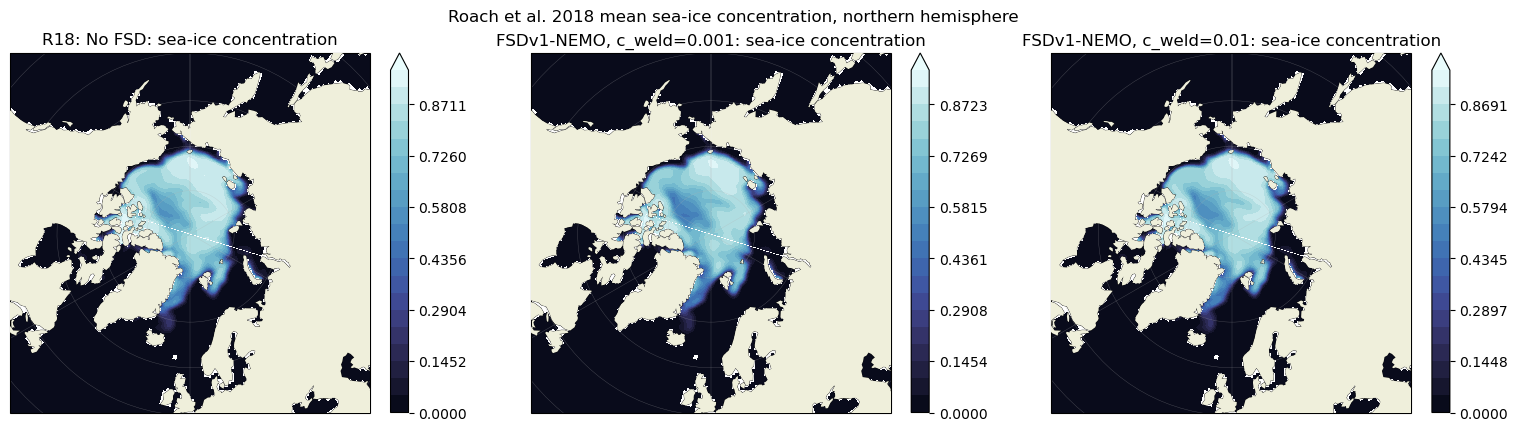

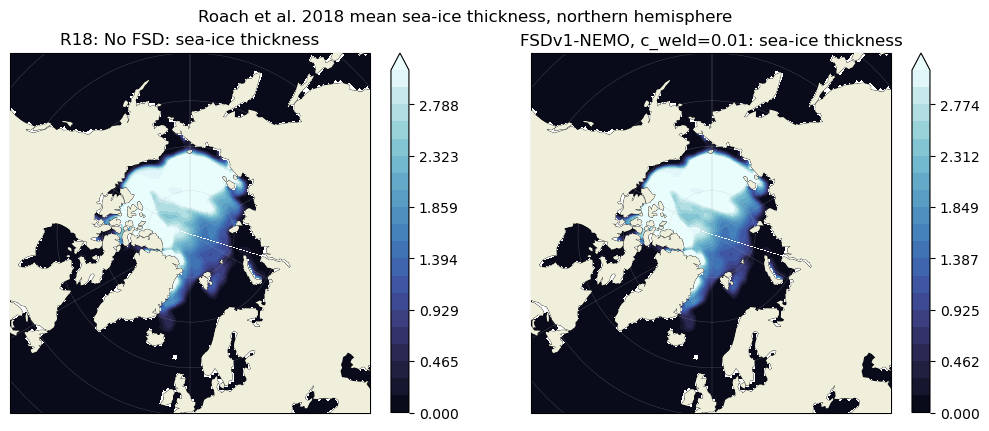

In [20]:
# R18
hemisphere = "north"
month = 8
state_vars = [("aice", "sea-ice concentration"), ("hi", "sea-ice thickness")]
for var, label in state_vars:
    cases = [case for case, ds in roach_2018.items() if var in ds]
    subplot_kw = {"projection": ccrs.NorthPolarStereo()} if HAS_CARTOPY else {}
    fig, axes = plt.subplots(1, len(cases), figsize=(5.2 * len(cases), 4.2), subplot_kw=subplot_kw, constrained_layout=True)
    if len(cases) == 1:
        axes = [axes]
    for ax, case in zip(axes, cases):
        da = monthly_mean(roach_2018[case][var], month)
        plot_map_panel(ax, da, roach_2018[case], f"{roach_2018_labels[case]}: {label}", cmap=ICE_CMAP)
        if HAS_CARTOPY:
            ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
    fig.suptitle(f"Roach et al. 2018 mean {label}, {hemisphere}ern hemisphere")
    mkmd.savefig("Maps of sea ice concentration and thickness", "Roach et al 2018")


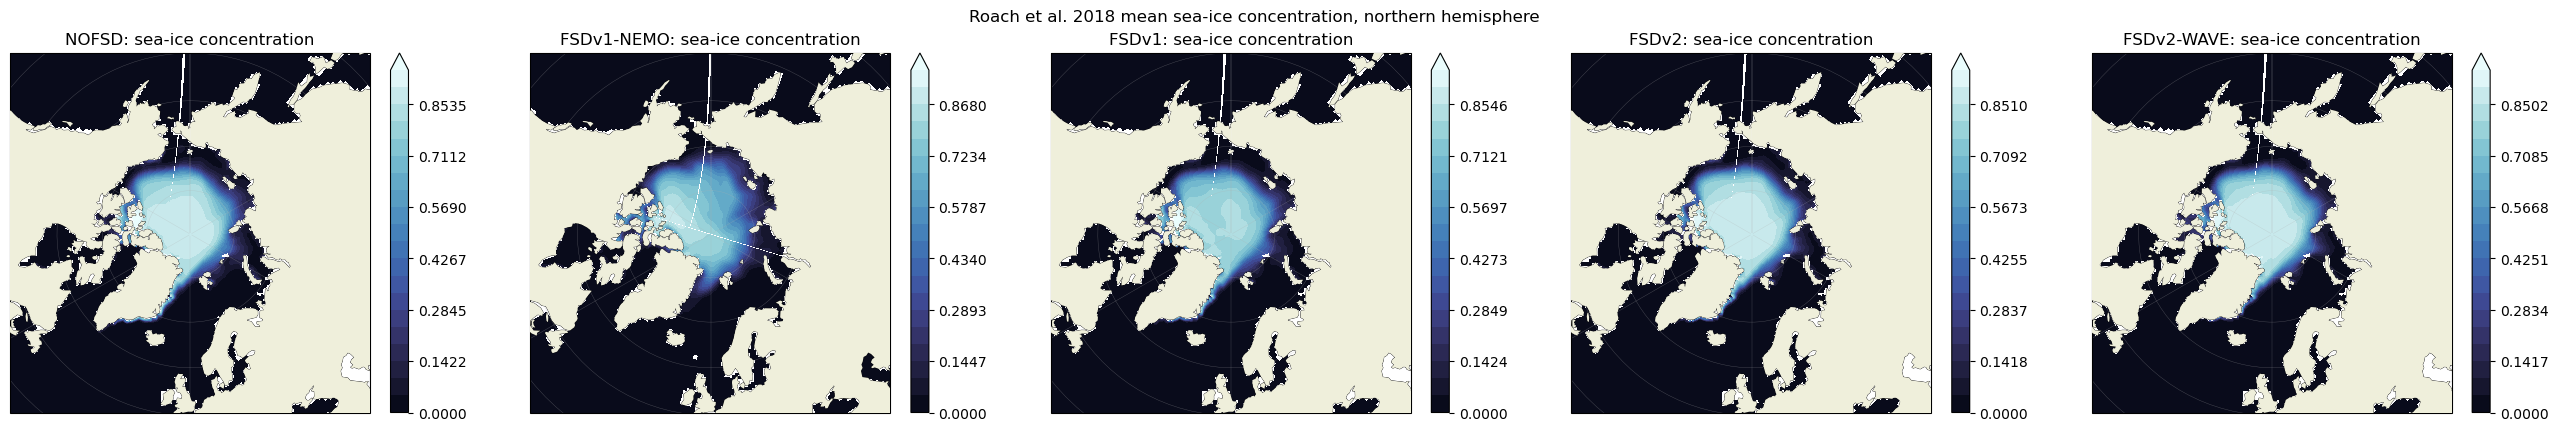

In [21]:
# R19
state_vars = [("aice", "sea-ice concentration")]
for var, label in state_vars:
    cases = [case for case, ds in roach_2019.items() if var in ds]
    subplot_kw = {"projection": ccrs.NorthPolarStereo()} if HAS_CARTOPY else {}
    fig, axes = plt.subplots(1, len(cases), figsize=(5.2 * len(cases), 4.2), subplot_kw=subplot_kw, constrained_layout=True)
    if len(cases) == 1:
        axes = [axes]
    for ax, case in zip(axes, cases):
        da = monthly_mean(roach_2019[case][var], month)
        plot_map_panel(ax, da, roach_2019[case], f"{case}: {label}", cmap=ICE_CMAP)
        if HAS_CARTOPY:
            ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
    fig.suptitle(f"Roach et al. 2018 mean {label}, {hemisphere}ern hemisphere")
    mkmd.savefig("Maps of sea ice concentration and thickness", "Roach et al 2019")


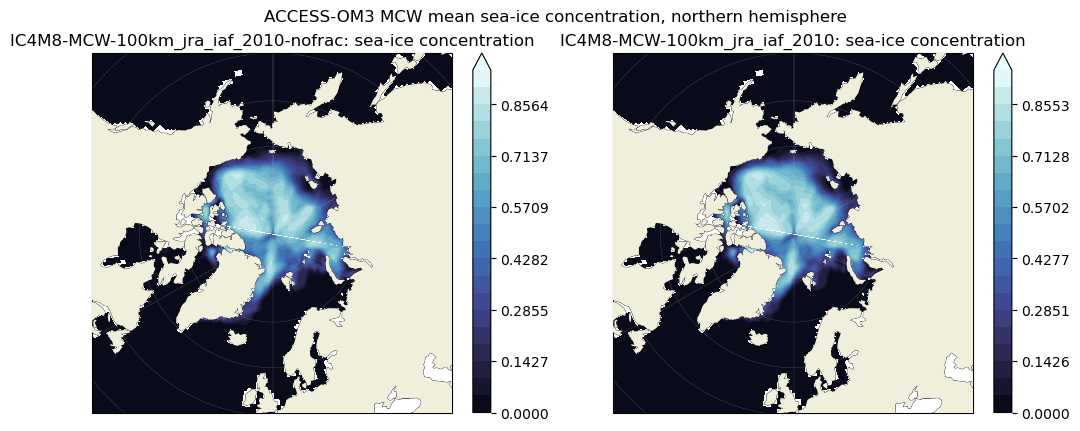

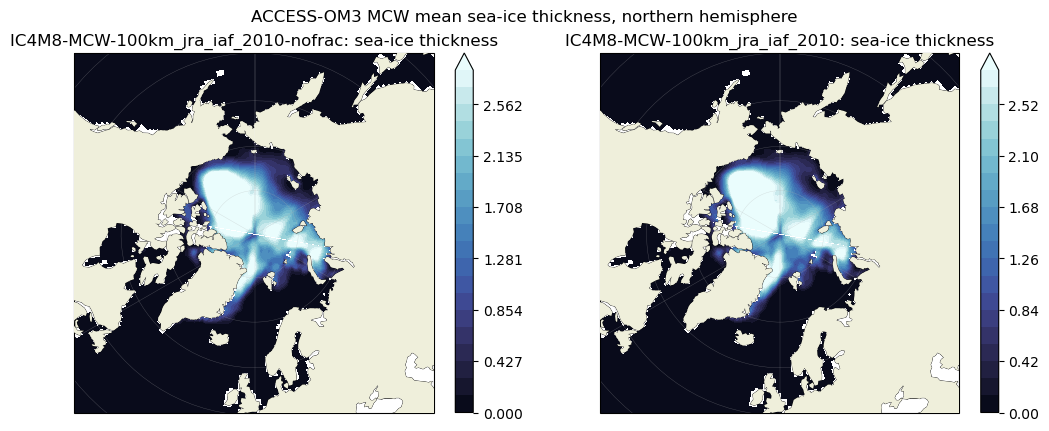

In [22]:
# MCW
state_vars = [("aice", "sea-ice concentration"), ("hi", "sea-ice thickness")]
for var, label in state_vars:
    cases = [case for case, ds in om3_datasets.items() if var in ds]
    subplot_kw = {"projection": ccrs.NorthPolarStereo()} if HAS_CARTOPY else {}
    fig, axes = plt.subplots(1, len(cases), figsize=(5.2 * len(cases), 4.2), subplot_kw=subplot_kw, constrained_layout=True)
    if len(cases) == 1:
        axes = [axes]
    for ax, case in zip(axes, cases):
        da = monthly_mean(om3_datasets[case][var], month)
        plot_map_panel(ax, da, om3_datasets[case], f"{case}: {label}", cmap=ICE_CMAP)
        if HAS_CARTOPY:
            ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
    fig.suptitle(f"ACCESS-OM3 MCW mean {label}, {hemisphere}ern hemisphere")
    mkmd.savefig("Maps of sea ice concentration and thickness", "Roach et al 2019")


## Maps of representative floe radius at both hemispheres
Roach et al. (2018) Figure 1

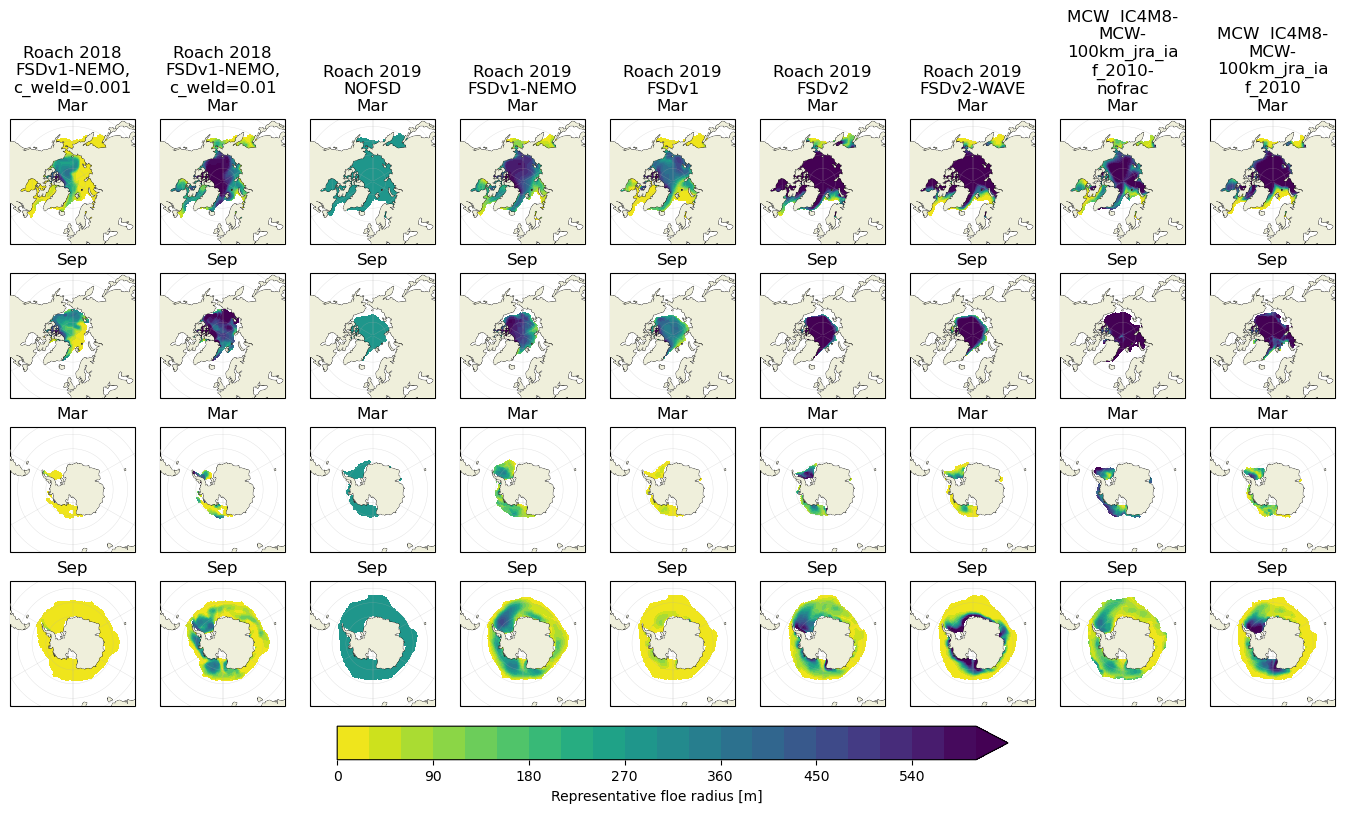

In [53]:
# Roach et al. 2018 Figure 1 analogue: representative floe radius with ACCESS-OM3 comparison.
fig_specs = [("north", 3), ("north", 9), ("south", 3), ("south", 9)]
fig_cases = {
    f"Roach 2018\n {roach_2018_labels["u-ai248i"]}": roach_2018["u-ai248i"],
    f"Roach 2018\n {roach_2018_labels["u-ai251i"]}": roach_2018["u-ai251i"],
    **{f"Roach 2019\n {key}": roach_2019[key] for key in roach_2019.keys()},
    **{f"MCW\n {key}": om3_datasets[key] for key in om3_datasets.keys()},
}

fig = plt.figure(figsize=(1.5*len(fig_cases), 2*len(fig_specs)), constrained_layout=True)
map_axes = []
mesh = None

for row, (hemi, month) in enumerate(fig_specs):
    for col, (case_label, ds) in enumerate(fig_cases.items()):
    
        if "fsdrad" in ds:
            ax = polar_axis(fig, len(fig_specs), len(fig_cases), row * len(fig_cases) + col + 1, hemi)
            map_axes.append(ax)
        else:
            continue
            
        da = monthly_mean(ds["fsdrad"], month)
        da_aice = monthly_mean(ds["aice"], month)
        da = da.where(da_aice > min_ice_area_fraction)
        da = hemi_mask(da, hemi, ds)
     
        if row == 0:
            plot_title = f"{textwrap.fill(case_label, width=12)}\n{month_name(month)}"
        else:
            plot_title = f"{month_name(month)}"
        mesh = plot_map_panel(
            ax,
            da,
            ds,
            plot_title,
            cmap="viridis_r",
            vmin=REP_RADIUS_LIMITS[0],
            vmax=REP_RADIUS_LIMITS[1],
            add_colorbar=False,
        )
        set_polar_extent(ax, hemi)

if mesh is not None:
    cbar = fig.colorbar(mesh, ax=map_axes, extend="max", orientation="horizontal", shrink=0.5, pad=0.03)
    cbar.set_label("Representative floe radius [m]")
mkmd.savefig("Floe size maps", "ACCESS-OM3 and Roach 2018/2019.")
plt.savefig(plotfolder + f"rep_radius_all_sims.png")

## Areal floe size distribution hemispheric averages

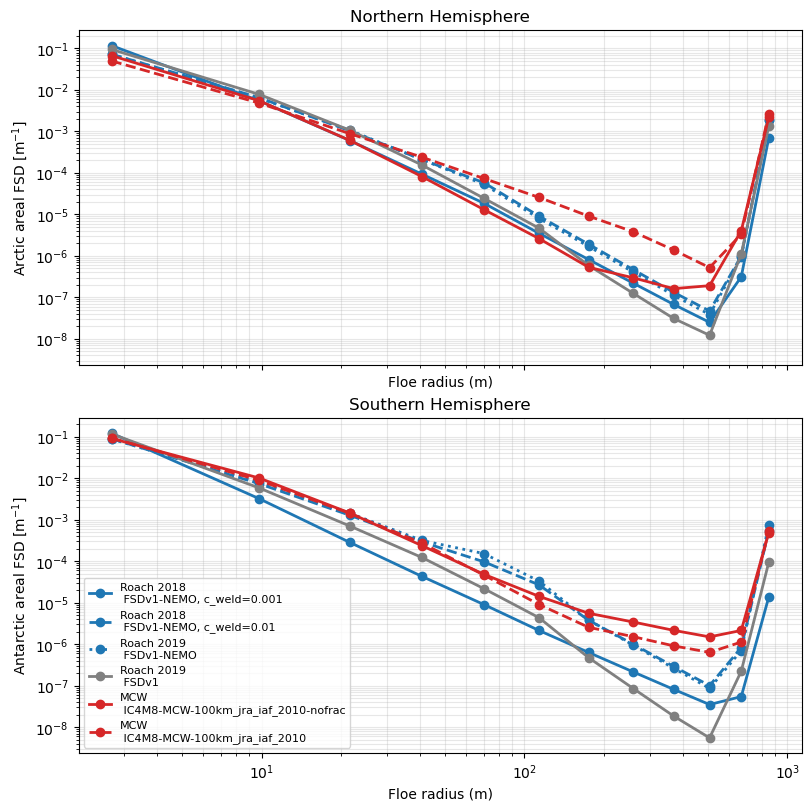

In [29]:
line_styles = ["-", "--", ":", "-."]

def case_group(case_label):
    if "FSDv1-NEMO" in case_label:
        return "FSDv1-NEMO"
    elif "FSDv2" in case_label:
        return "FSDv2"
    elif "FSDv1" in case_label:
        return "FSDv1"
    elif "MCW" in case_label:
        return "MCW"
    else:
        return "Other"


group_colors = {
    "FSDv1-NEMO": "tab:blue",
    "FSDv1": "gray",
    "FSDv2": "tab:green",
    "MCW": "tab:red",
    "Other": "k",
}

# Assign a stable linestyle for each case label
group_counts = {}
case_line_specs = {}

for case_label in fig_cases:
    group = case_group(case_label)
    count = group_counts.get(group, 0)

    case_line_specs[case_label] = {
        "color": group_colors[group],
        "linestyle": line_styles[count % len(line_styles)],
    }

    group_counts[group] = count + 1
    

fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 8),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, hemi, hemi_label in zip(
    axes,
    ["north", "south"],
    ["Northern Hemisphere", "Southern Hemisphere"],
):
    for case_label, ds in fig_cases.items():
        if "afsd" not in ds:
            continue

        afsd = ds["afsd"].where(ds["aice"] > 0.15)
        afsd = hemi_weighted_mean(afsd, ds, hemi).mean("time")

        spec = case_line_specs[case_label]

        ax.plot(
            ds["NFSD"],
            afsd,
            marker="o",
            linewidth=2.0,
            color=spec["color"],
            linestyle=spec["linestyle"],
            label=case_label,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(hemi_label)
    ax.grid(True, alpha=0.3, which="both")

axes[0].set_ylabel("Arctic areal FSD [m$^{-1}$]")
axes[1].set_ylabel("Antarctic areal FSD [m$^{-1}$]")

for ax in axes:
    ax.set_xlabel("Floe radius (m)")

axes[-1].legend(loc="best", fontsize=8)

mkmd.savefig(
    "Areal floe size distribution hemispheric averages",
    "ACCESS-OM3 and Roach 2018/2019.",
)

## Number floe size distribution and tendencies (hemispheric averages)
Roach et al. (2018) Figure 2

In [30]:
tendency_linespecs = {
    "dafsd_latm_n": "#1b9e77",
    "dafsd_latg_n": "#001480",
    "dafsd_newi_n": "#ffa500",
    "dafsd_weld_n": "#86ceeb",
    "dafsd_wave_n": "#ff6347",
}
def tendency_label(var):
    base = (
        var
        .removesuffix("_n")
        .removesuffix("_ra")
    )

    aliases = {
        "dafsd_new": "dafsd_newi",
    }

    base = aliases.get(base, base)

    return TENDENCY_LABELS.get(base, var)

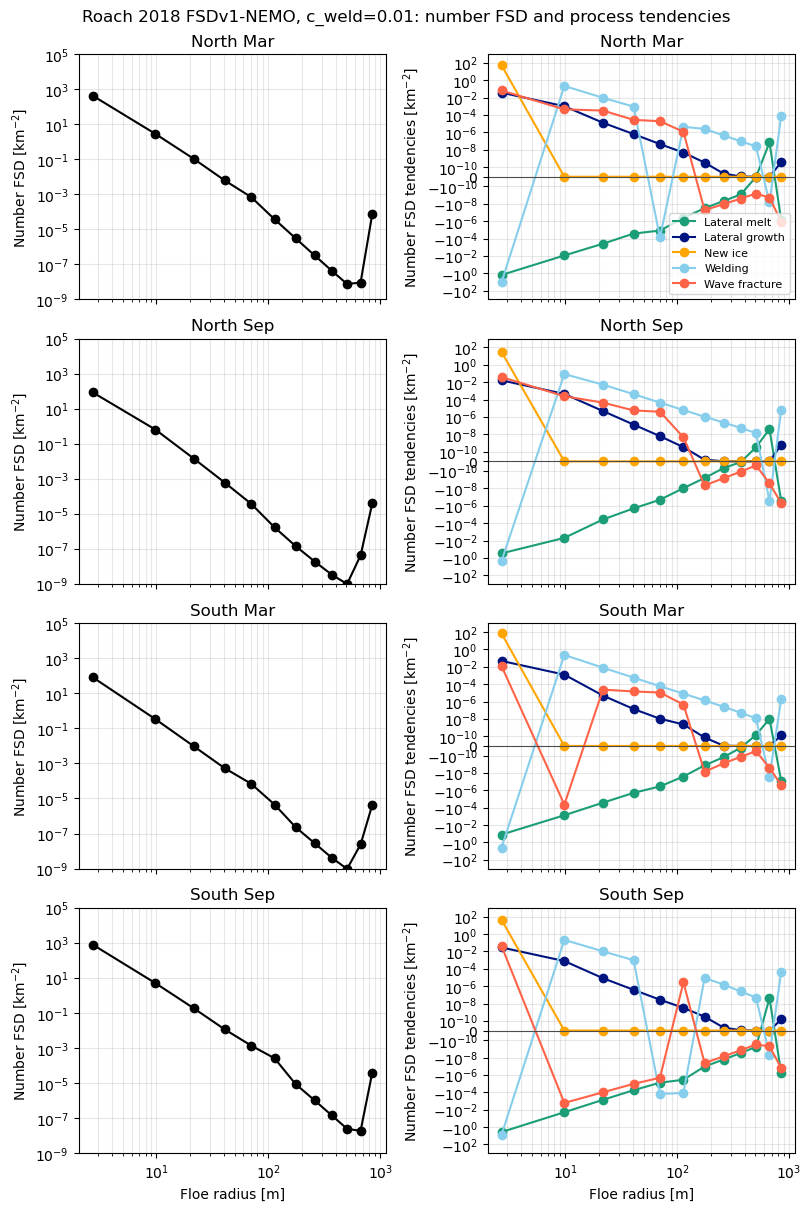

In [31]:
# Roach et al. 2018 Figure 2 analogue: number FSDs and process tendency
fig, axes = plt.subplots(4, 2, figsize=(8, 12), constrained_layout=True, sharex=True)

for row, (hemi, month) in enumerate(fig_specs):
    ax = axes[row, 0]
    ds = roach_2018["u-ai251i"]
    da = hemi_weighted_mean(ds["nfsd"], ds, hemi)
    dist = monthly_mean(da, month)
    ax.plot(ds["NFSD"], dist, marker="o", color='k')
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(1e-9, 1e5)
    ax.set_title(f"{hemi.title()} {month_name(month)}")
    ax.set_ylabel("Number FSD [km$^{-2}$]")
    ax.grid(True, alpha=0.3, which="both")
    
    ax = axes[row, 1]
    for var in tendency_linespecs.keys():
        da = hemi_weighted_mean(ds[var], ds, hemi)
        dist = monthly_mean(da, month)
        ax.plot(ds["NFSD"], dist, marker='o', color=tendency_linespecs[var], label=tendency_label(var))

    ax.axhline(0, color="0.3", linewidth=0.8)
    ax.set_xscale("log")
    ax.set_yscale("symlog", linthresh=1e-10)
    ax.set_ylim(-1e3, 1e3)
    ax.set_title(f"{hemi.title()} {month_name(month)}")
    ax.set_ylabel("Number FSD tendencies [km$^{-2}$]")
    ax.grid(True, alpha=0.3, which="both")

axes[0, 1].legend(loc="best", fontsize=8)
axes[-1,0].set_xlabel("Floe radius [m]")
axes[-1,1].set_xlabel("Floe radius [m]")


fig.suptitle(f"Roach 2018 {roach_2018_labels['u-ai251i']}: number FSD and process tendencies")
mkmd.savefig("Areal floe size distribution hemispheric tendencies", "ACCESS-OM3 and Roach 2018.")

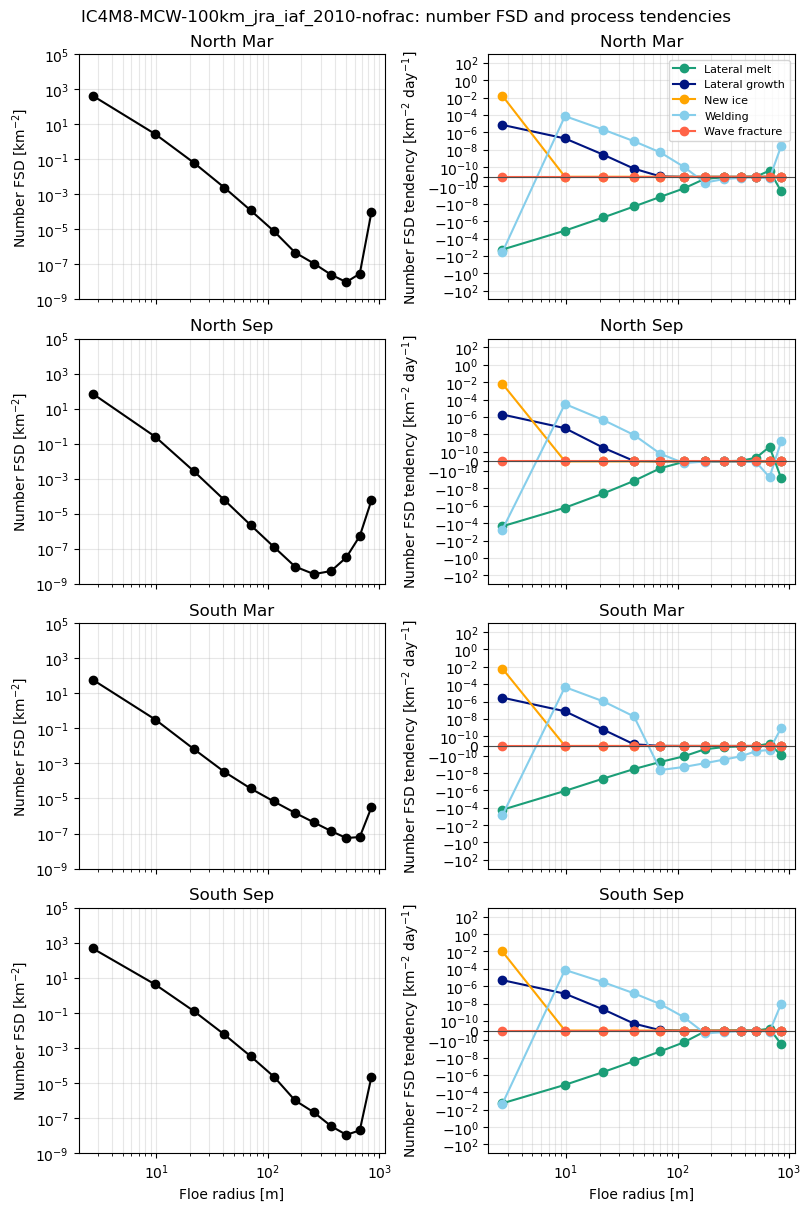

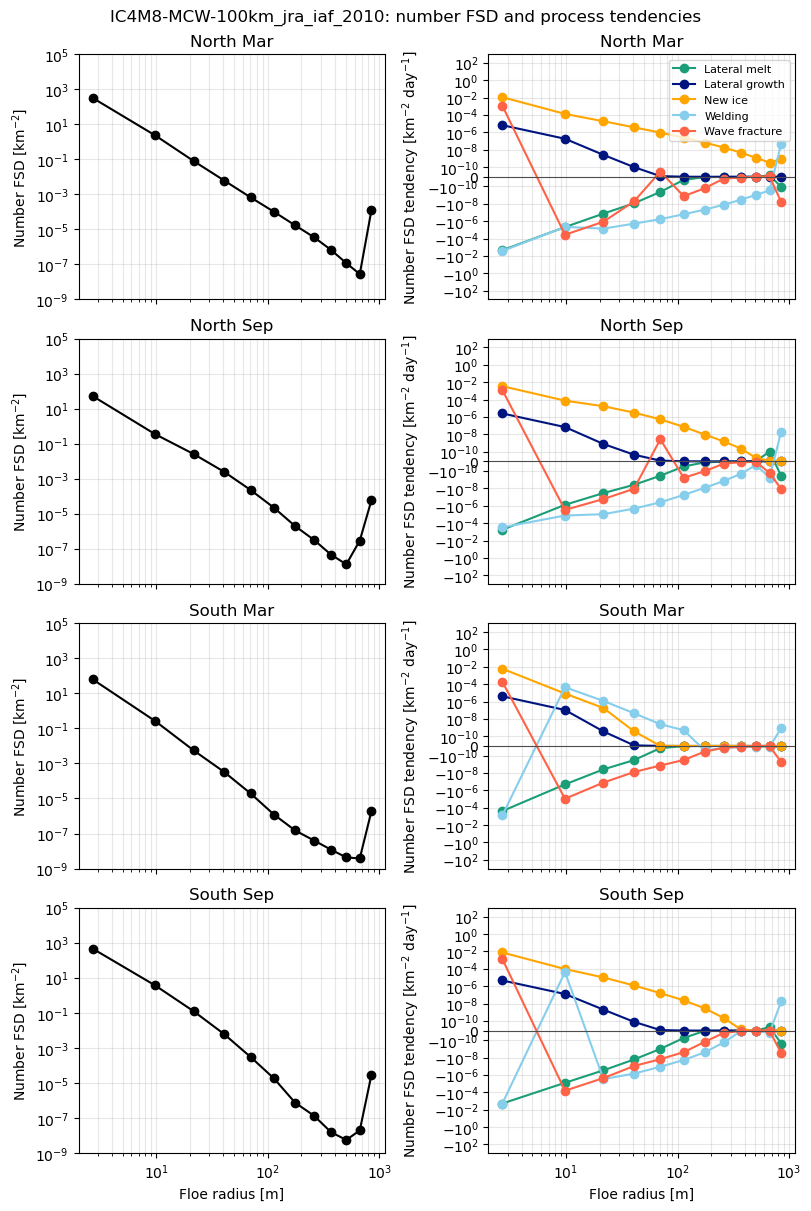

In [32]:
# Respective plot for ACCESS-OM3 outputs

for case, ds in om3_datasets.items():
    if "nfsd" not in ds:
        continue
    fig, axes = plt.subplots(4, 2, figsize=(8, 12), constrained_layout=True, sharex=True)
    
    for row, (hemi, month) in enumerate(fig_specs):
        ax = axes[row, 0]
        da = hemi_weighted_mean(ds["nfsd"], ds, hemi)
        dist = monthly_mean(da, month)
        ax.plot(ds["NFSD"], dist, marker="o", color='k')
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_ylim(1e-9, 1e5)
        ax.set_title(f"{hemi.title()} {month_name(month)}")
        ax.set_xlabel("")
        ax.set_ylabel("Number FSD [km$^{-2}$]")
        ax.grid(True, alpha=0.3, which="both")
    
        ax = axes[row, 1]
        for var in tendency_linespecs.keys():
            da = hemi_weighted_mean(ds[var], ds, hemi)
            dist = monthly_mean(da, month)
            ax.plot(ds["NFSD"], dist, marker='o', color=tendency_linespecs[var], label=tendency_label(var))
    
        ax.axhline(0, color="0.3", linewidth=0.8)
        ax.set_xscale("log")
        ax.set_yscale("symlog", linthresh=1e-10)
        ax.set_ylim(-1e3, 1e3)
        ax.set_title(f"{hemi.title()} {month_name(month)}")
        ax.set_xlabel("")
        ax.set_ylabel("Number FSD tendency [km$^{-2}$ day$^{-1}$]")
        ax.grid(True, alpha=0.3, which="both")
    
    axes[0, 1].legend(loc="best", fontsize=8)
    axes[-1,0].set_xlabel("Floe radius [m]")
    axes[-1,1].set_xlabel("Floe radius [m]")
    
    fig.suptitle(f"{case}: number FSD and process tendencies")
    mkmd.savefig("Areal floe size distribution hemispheric tendencies", f"ACCESS-OM3 {case} and Roach 2018.")

## Seasonal and spatial variability of representative radii
Roach et al. (2018) Figure 3


In [33]:
def data_vars_starting(ds, prefixes):
    return [
        name
        for name in ds.data_vars
        if isinstance(name, str) and any(name.startswith(prefix) for prefix in prefixes)
    ]

roach_2018_tendency_vars = data_vars_starting(roach_2018["u-ai251i"], ["dafsd"])

roach_2018_tendency_vars = [
    name for name in roach_2018_tendency_vars
    if len(name) == 12
]

roach_2018_tendency_vars

['dafsd_latm_n',
 'dafsd_latg_n',
 'dafsd_newi_n',
 'dafsd_weld_n',
 'dafsd_wave_n']

In [34]:
tendency_map_specs = [
    ("dafsd_latm_ra", 7, 1, "Lateral melt", 0.92, 0.43),
    ("dafsd_latg_ra", 10, 3, "Lateral growth", 2.44e-3, 2.60e-3),
    ("dafsd_newi_ra", 11, 4, "New ice", 0.22, 2.40),
    ("dafsd_weld_ra", 1, 5, "Welding", 4.18, 7.58),
    ("dafsd_wave_ra", 7, 2, "Wave fracture", 2.18, 1.74),
]

map_datasets_2018 = {
    f"Roach 2018 {roach_2018_labels['u-ai251i']}": roach_2018["u-ai251i"],
    f"ACCESS-OM3 {BASELINE_LABEL}": om3_datasets[BASELINE_LABEL],
    f"ACCESS-OM3 {OM3_LABEL}": om3_datasets[OM3_LABEL],
}

Roach 2018 FSDv1-NEMO, c_weld=0.01 ['dafsd_latm_ra', 'dafsd_latg_ra', 'dafsd_newi_ra', 'dafsd_weld_ra', 'dafsd_wave_ra']
ACCESS-OM3 IC4M8-MCW-100km_jra_iaf_2010-nofrac ['dafsd_latm_ra', 'dafsd_latg_ra', 'dafsd_newi_ra', 'dafsd_weld_ra', 'dafsd_wave_ra']
ACCESS-OM3 IC4M8-MCW-100km_jra_iaf_2010 ['dafsd_latm_ra', 'dafsd_latg_ra', 'dafsd_newi_ra', 'dafsd_weld_ra', 'dafsd_wave_ra']


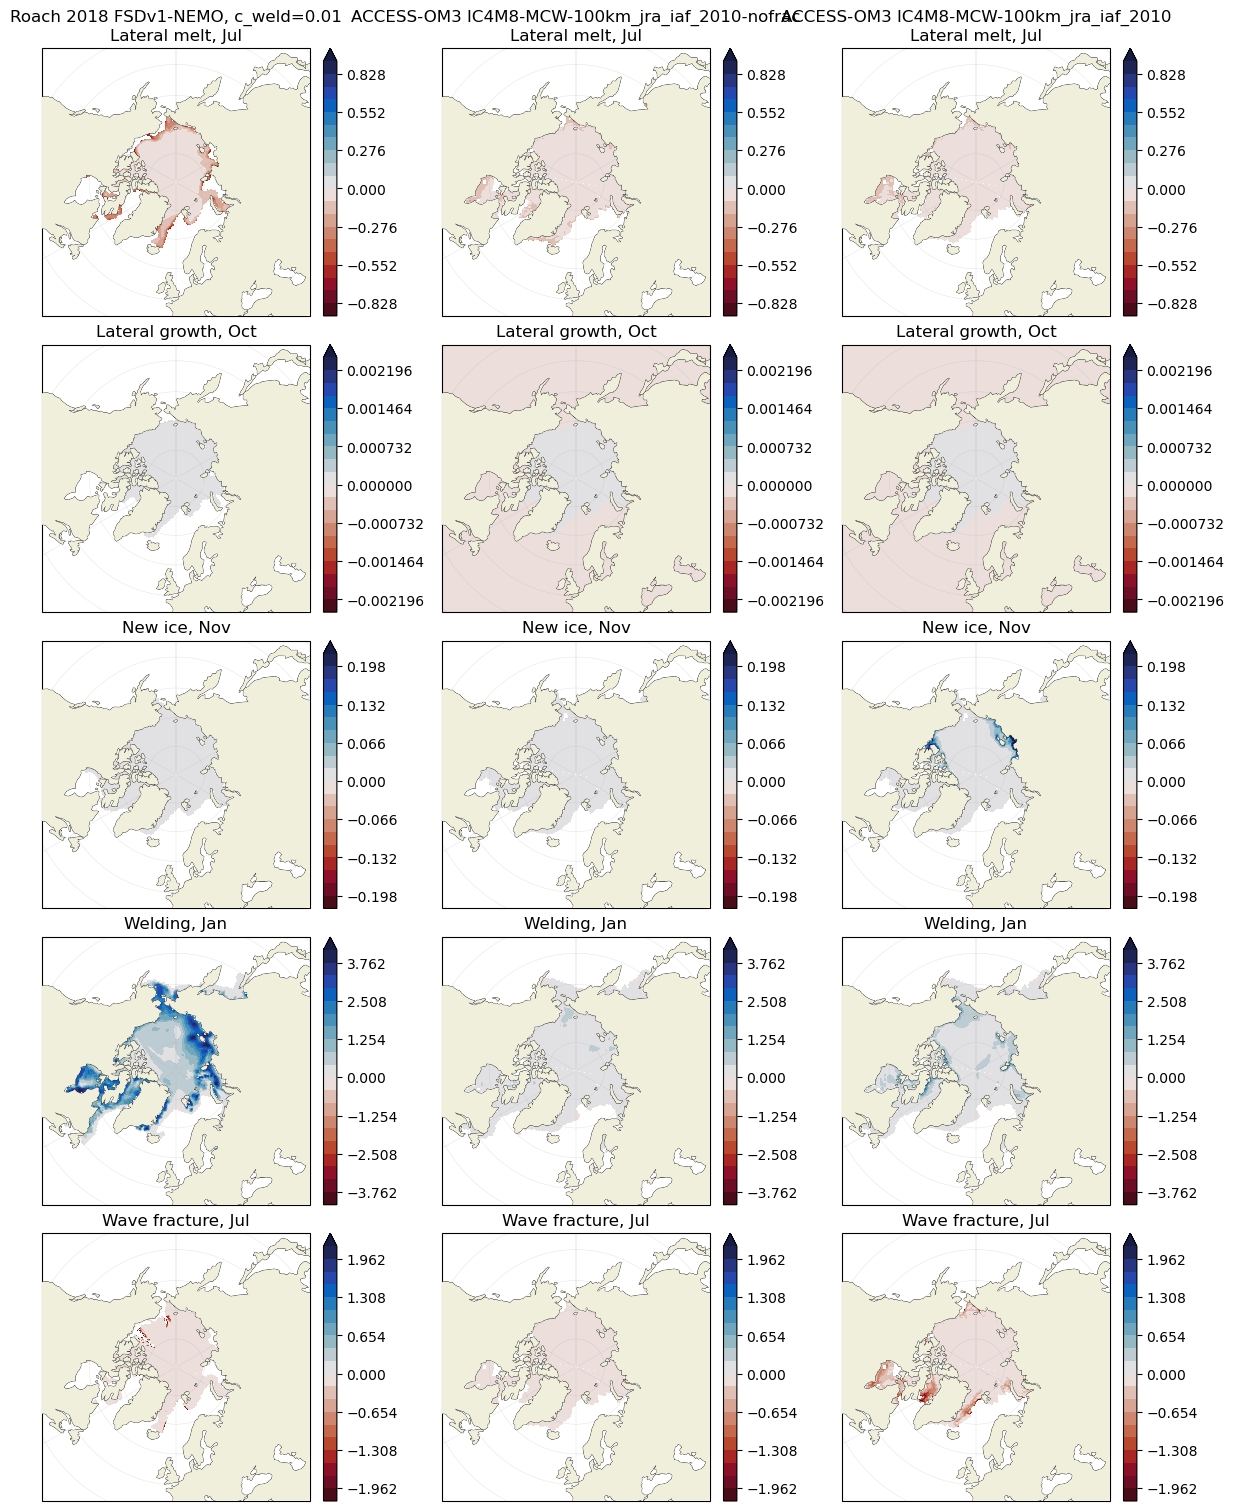

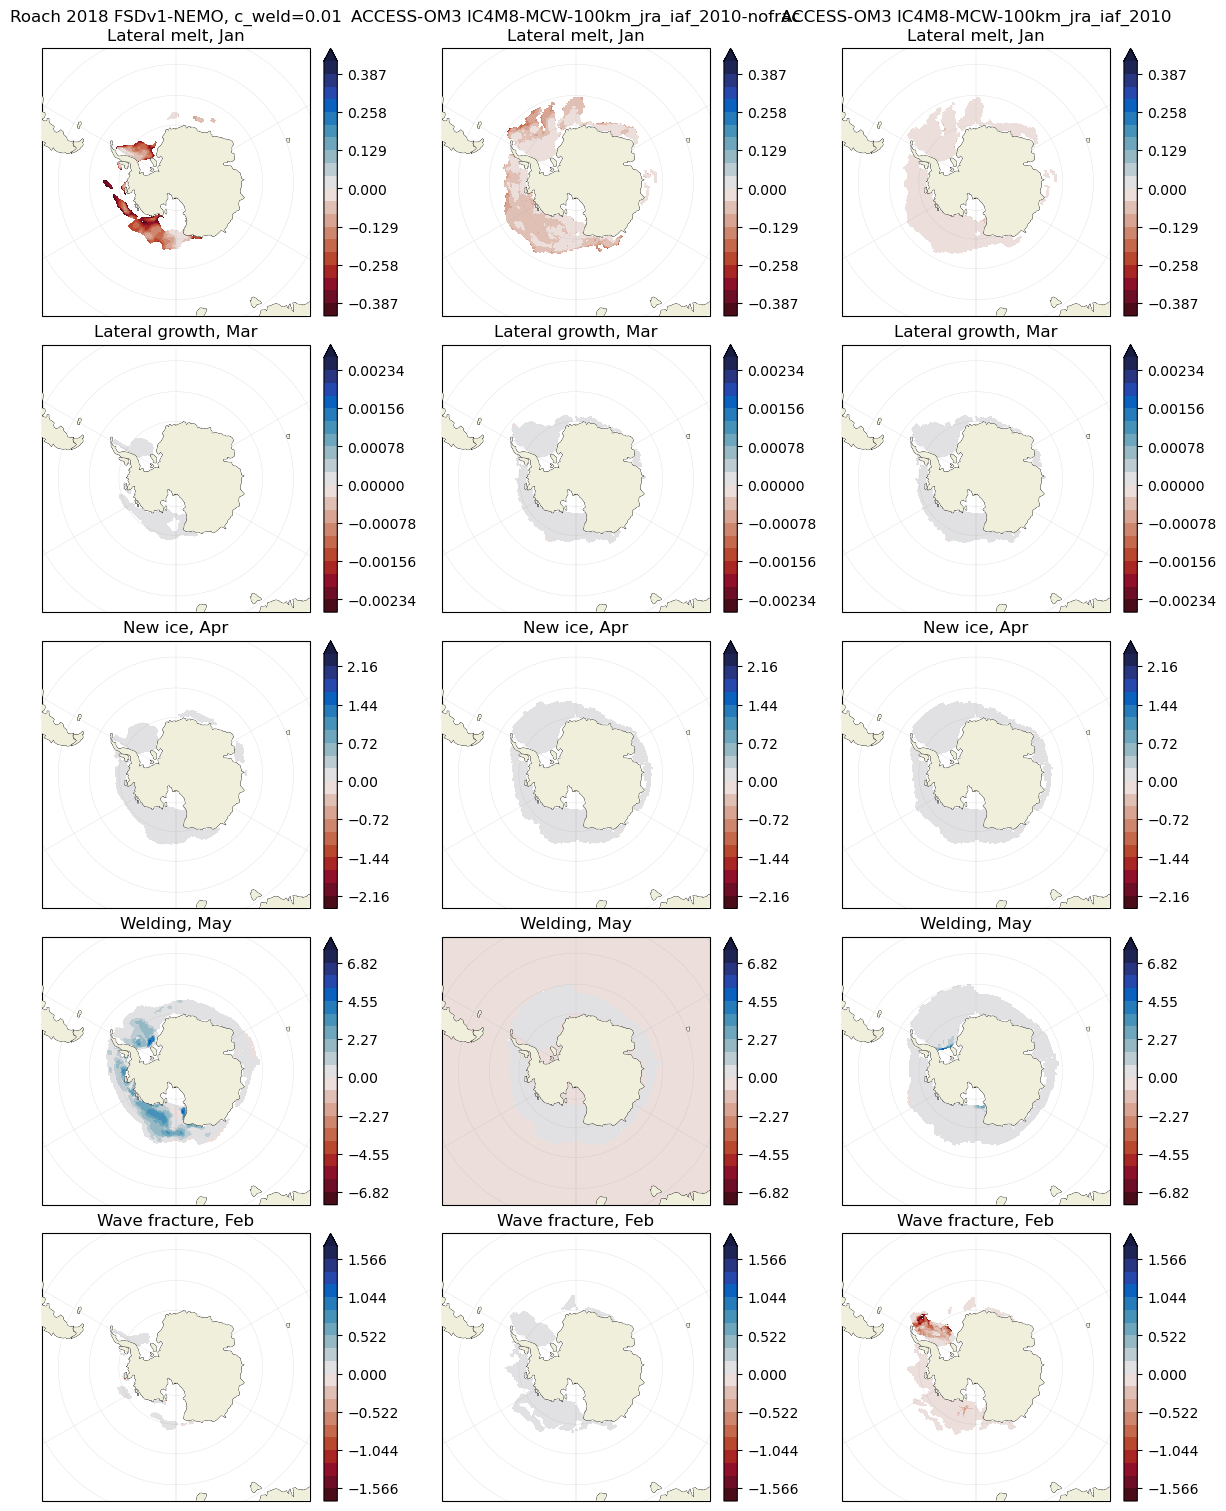

In [35]:
for label, ds in map_datasets_2018.items():
    print(label, [v for v, *_ in tendency_map_specs if v in ds])

for hemi, month_index, lim_index, hemi_label in [
    ("north", 1, 4, "Northern Hemisphere"),
    ("south", 2, 5, "Southern Hemisphere"),
]:
    fig = plt.figure(figsize=(4*len(map_datasets_2018), 3*len(tendency_map_specs)), constrained_layout=True)
    gs = fig.add_gridspec(len(tendency_map_specs), len(map_datasets_2018))

    for row, spec in enumerate(tendency_map_specs):
        var = spec[0]
        month = spec[month_index]
        label = spec[3]
        lim = spec[lim_index]

        for col, (case_label, ds) in enumerate(map_datasets_2018.items()):
            ax = polar_axis(
                fig,
                len(tendency_map_specs),
                len(map_datasets_2018),
                row * len(map_datasets_2018) + col + 1,
                hemi,
            )

            if var not in ds:
                ax.text(
                    0.5,
                    0.5,
                    "not available",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_title(case_label if row == 0 else "")
                ax.set_axis_off()
                continue

            if case_label.startswith("ACCESS-OM3"):
                vmin = -lim * TENDENCY_SCALE
                vmax = lim * TENDENCY_SCALE
            else:
                vmin = -lim
                vmax = lim

            title = (
                f"{case_label}\n{label}, {month_name(month)}"
                if row == 0
                else f"{label}, {month_name(month)}"
            )
            da = mean_over_time_month(ds[var], month).squeeze(drop=True)
            plot_map_panel(
                ax,
                da,
                ds,
                title,
                cmap=BALANCE_CMAP_R,
                vmin=vmin,
                vmax=vmax,
                add_colorbar=True,
            )
            # add_ice_contours(ax, da_aice, ds, hemi)

            set_polar_extent(ax, hemi)
    mkmd.savefig(f"Seasonal and spatial variability of representative radii {hemi}ern hemisphere", f"ACCESS-OM3 and Roach 2018.")

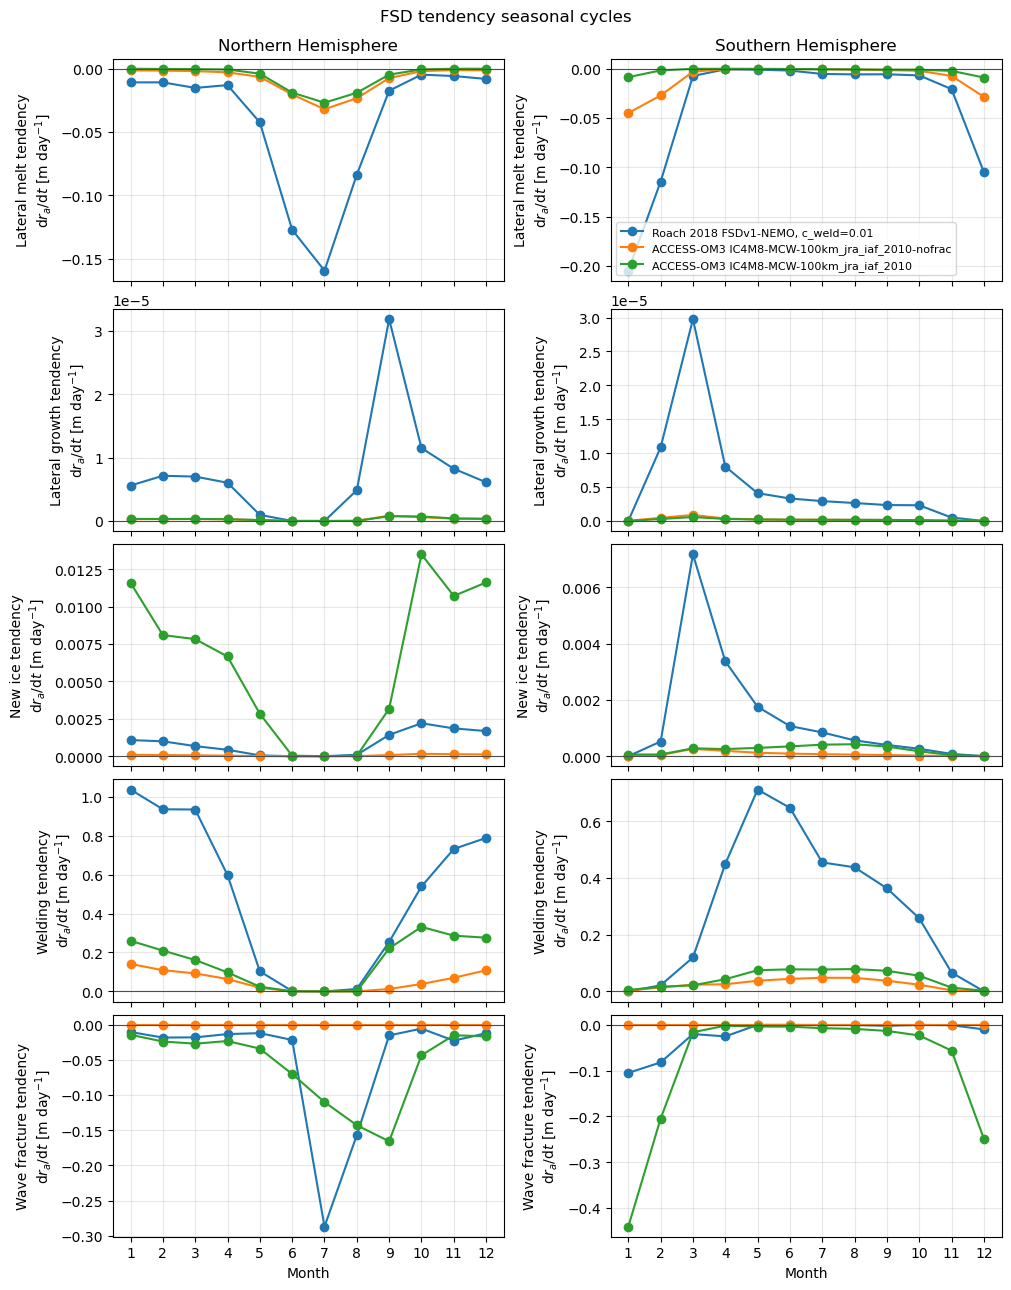

In [36]:
seasonal_cases = {
    f"Roach 2018 {roach_2018_labels['u-ai251i']}": roach_2018["u-ai251i"],
    f"ACCESS-OM3 {BASELINE_LABEL}": om3_datasets[BASELINE_LABEL],
    f"ACCESS-OM3 {OM3_LABEL}": om3_datasets[OM3_LABEL],
}

hemispheres = [
    ("north", "Northern Hemisphere"),
    ("south", "Southern Hemisphere"),
]

nrows = len(tendency_map_specs)
ncols = len(hemispheres)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5*ncols, 2.5 * nrows),
    sharex=True,
    constrained_layout=True,
)

axes = np.atleast_2d(axes)

for row, (var, north_month, south_month, label, north_lim, south_lim) in enumerate(tendency_map_specs):
    for col, (hemi, hemi_label) in enumerate(hemispheres):
        ax = axes[row, col]

        for case_label, ds in seasonal_cases.items():
            if var not in ds:
                continue

            dafsd_ra = (
                hemi_weighted_mean(ds[var], ds, hemi)
                .groupby("time.month")
                .mean("time")
            )

            ax.plot(
                dafsd_ra.month,
                dafsd_ra.values,
                marker="o",
                label=case_label,
            )

        ax.axhline(0, color="0.3", linewidth=0.8)
        ax.set_ylabel(
            rf"{label} tendency" "\n"
            r"$\mathrm{d} r_a / \mathrm{d}t$ [m day$^{-1}$]"
        )
        ax.grid(True, alpha=0.3)

        if row == nrows - 1:
            ax.set_xlabel("Month")
        else:
            ax.set_xlabel("")

        ax.set_xticks(range(1, 13))
        axes[0,col].set_title(f"{hemi_label}")

    
# One legend for the full figure
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0,1].legend(
    handles,
    labels,
    loc="lower left",
    ncol=1,
    fontsize=8,
)

fig.suptitle(
    "FSD tendency seasonal cycles",
    y=1.02,
)
mkmd.savefig(f"Seasonal and spatial variability of floe size tendencies", f"ACCESS-OM3 and Roach 2018.")

## Differences in sea ice concentration and ice thickness

AttributeError: cannot set attribute 'name' on a 'Dataset' object. Use __setitem__ styleassignment (e.g., `ds['name'] = ...`) instead of assigning variables.

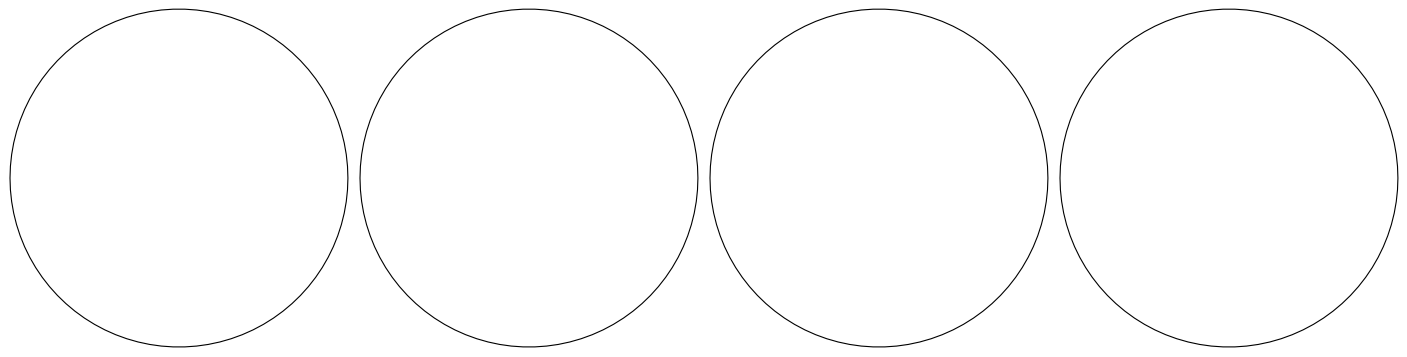

In [37]:
# Roach et al. 2018 Figures 4 and 5 analogues:
# baseline model state, FSD-minus-baseline differences, ACCESS-OM3 state, and ACCESS-OM3-minus-baseline.
for var, label, cmap in [
    ("aice", "Sea-ice concentration", ICE_CMAP),
    # ("hi", "Sea-ice volume per unit area", ICE_CMAP),
]:
    nrows = len(fig_specs)
    ncols = 4

    fig = plt.figure(figsize=(3.5*ncols, 3.4 * nrows), constrained_layout=True)
    axes = np.empty((nrows, ncols), dtype=object)

    for row, (hemi, month) in enumerate(fig_specs):
        for col in range(ncols):
            axes[row, col] = polar_axis(
                fig,
                nrows,
                ncols,
                ncols * row + col + 1,
                hemi,
            )

        baseline = monthly_mean(roach_2018["u-ai245i"][var], month)
        fsd = monthly_mean(roach_2018["u-ai248i"][var], month)

        diff = fsd - baseline
        diff.name = f"{var}_FSD_minus_baseline"

        ds_om3 = om3_datasets[OM3_LABEL]
        ds_om3_baseline = om3_datasets[BASELINE_LABEL]
        om3_da = monthly_mean(ds_om3[var], month) if var in ds_om3 else None
        if om3_da is not None:
            om3_da = subset_named_hemisphere(om3_da, ds_om3, hemi)

            diff_om3 = ds_om3 - ds_om3_baseline
            diff_om3.name = f"{var}_ACCESS_OM3_minus_baseline"

        plot_map_panel(
            axes[row, 0],
            baseline,
            roach_2018["u-ai245i"],
            f"Roach baseline\n{hemi.upper()} {month_name(month)}",
            cmap=cmap,
        )

        plot_map_panel(
            axes[row, 1],
            diff,
            roach_2018["u-ai248i"],
            f"Roach FSD - baseline\n{hemi.upper()} {month_name(month)}",
            cmap=BALANCE_CMAP,
        )

        if om3_da is not None:
            plot_map_panel(
                axes[row, 2],
                om3_da,
                ds_om3,
                f"ACCESS-OM3\n{hemi.upper()} {month_name(month)}",
                cmap=cmap,
            )

            plot_map_panel(
                axes[row, 3],
                diff_om3,
                ds_om3,
                f"ACCESS-OM3 - baseline\n{hemi.upper()} {month_name(month)}",
                cmap=BALANCE_CMAP,
            )
        else:
            axes[row, 2].set_axis_off()
            axes[row, 3].set_axis_off()

        for ax in axes[row, :]:
            set_polar_extent(ax, hemi)
    mkmd.savefig(f"Differences in sea ice concentration and ice thickness {label}", f"ACCESS-OM3 and Roach 2018.")

## Open Roach et al. (2019) data

These cells follow the main figures in Roach et al. (2019): floe perimeter per unit ice area (Fig. 1), representative floe radius (Fig. 2), Arctic process seasonality in FSDv2-WAVE (Fig. 3), significant wave height (Fig. 4), lateral/basal melt relationships (Fig. 5), and ice-volume differences relative to NOFSD (Fig. 6). The code discovers coordinates and skips unavailable variables where needed.


In [38]:
# overwrite_regridded_roach = False
# roach_2019_dir = Path(roach_data_dir)
# roach_2019_case_files = {
#     "NOFSD": "cice_NOFSD_LR_2000-2014.nc",
#     "FSDv1-NEMO": "cice_FSDv1-NEMO_LR_2000-2014.nc",
#     "FSDv1": "cice_FSDv1_LR_2000-2014.nc",
#     "FSDv2": "cice_FSDv2_LR_2000-2014.nc",
#     "FSDv2-WAVE": "cice_FSDv2-WAVE_LR_2000-2014.nc",
# }

# ROACH_2019_RENAMES = {
#     "areal_fsd": "afsd",
#     "dafsdani": "dafsd_newi",
#     "dafsdlatg": "dafsd_latg",
#     "dafsdlatm": "dafsd_latm",
#     "dafsdmrg": "dafsd_weld",
#     "dafsdwave": "dafsd_wave",
# }

# RADIUS_TENDENCY_LIMIT = 100.0
# DAYS_PER_YEAR = 365.0

# def open_roach_2019_case(filename):
#     ds = xr.open_dataset(roach_2019_dir / filename, chunks={"time": "auto"}, decode_times=True)
#     renames = {old: new for old, new in ROACH_2019_RENAMES.items() if old in ds and new not in ds}
#     if "nkfsd" in ds.dims:
#         ds = ds.rename({"nkfsd": "nf"})
#     ds = ds.rename(renames) if renames else ds
#     ds.attrs["fsd_is_density"] = False
#     return ds


# roach_2019_native = {
#     case: open_roach_2019_case(filename)
#     for case, filename in roach_2019_case_files.items()
#     if (roach_2019_dir / filename).exists()
# }

# roach_2019 = {}
# for case, ds in roach_2019_native.items():
#     if REGRID_ROACH_DATASETS:
#         cache = regrid_cache_path(roach_2019_dir, f"{case}_regridded_to_{OM3_LABEL}")
#         roach_2019[case] = regrid_dataset_to_om3(ds, ds_om3, cache, overwrite=overwrite_regridded_roach)
#     else:
#         roach_2019[case] = roach_2019_native[case]
#     roach_2019[case].attrs["fsd_is_density"] = ds.attrs.get("fsd_is_density", False)
#     if "NFSD" not in roach_2019[case] and "NFSD" in ds:
#         roach_2019[case] = roach_2019[case].assign_coords({"NFSD": ds["NFSD"]})
#     if "nfsd" not in roach_2019[case] and "afsd" in roach_2019[case]:
#         roach_2019[case] = number_fsd(roach_2019[case], area_unit="km")
#     if "fsdrad" not in roach_2019[case] and "afsd" in roach_2019[case]:
#         roach_2019[case] = representative_radius(roach_2019[case])
#     if "fsdperim" not in roach_2019[case] and "afsd" in roach_2019[case]:
#         roach_2019[case] = perimeter_per_ice_area(roach_2019[case], length_unit="km")
#     elif "fsdperim" in roach_2019[case]:
#         roach_2019[case]["fsdperim"] = roach_2019[case]["fsdperim"]
        
#     if "dafsd_latm" in roach_2019[case]:
#         for var in ["dafsd_latm", "dafsd_latg", "dafsd_newi", "dafsd_weld", "dafsd_wave"]:
#             if var not in roach_2019[case]:
#                 continue

#             roach_2019[case] = integrate_radius_tendency(
#                 roach_2019[case],
#                 var,
#                 input_time_unit="m",
#                 output_time_unit="d",
#             )
            
#             roach_2019[case] = number_fsd_tendency(
#                 roach_2019[case],
#                 var,
#                 time_unit="d",
#                 area_unit="km",
#             )

# wave_2019 = None
# if (roach_2019_dir / wave_file).exists():
#     wave_native = xr.open_dataset(roach_2019_dir / wave_file, chunks={"time": "auto"})
#     wave_cache = regrid_cache_path(roach_2019_dir, f"wave_FSDv2-WAVE_regridded_to_{OM3_LABEL}")
#     wave_2019 = regrid_dataset_to_om3(wave_native, ds_om3, wave_cache, overwrite=overwrite_regridded_roach)


In [39]:
# roach_2019["NOFSD"]["fsdperim"] = xr.full_like(roach_2019["NOFSD"]["aice"], NOFSD_PERIMETER_KM)
# roach_2019["NOFSD"]["fsdperim"].attrs.update({
#     "long_name": "Floe perimeter per unit ice area",
#     "units": "km-1",
# })

## Floe perimeter per unit sea ice area: maps and seasonal cycle
Roach et al. (2019) Figure 1

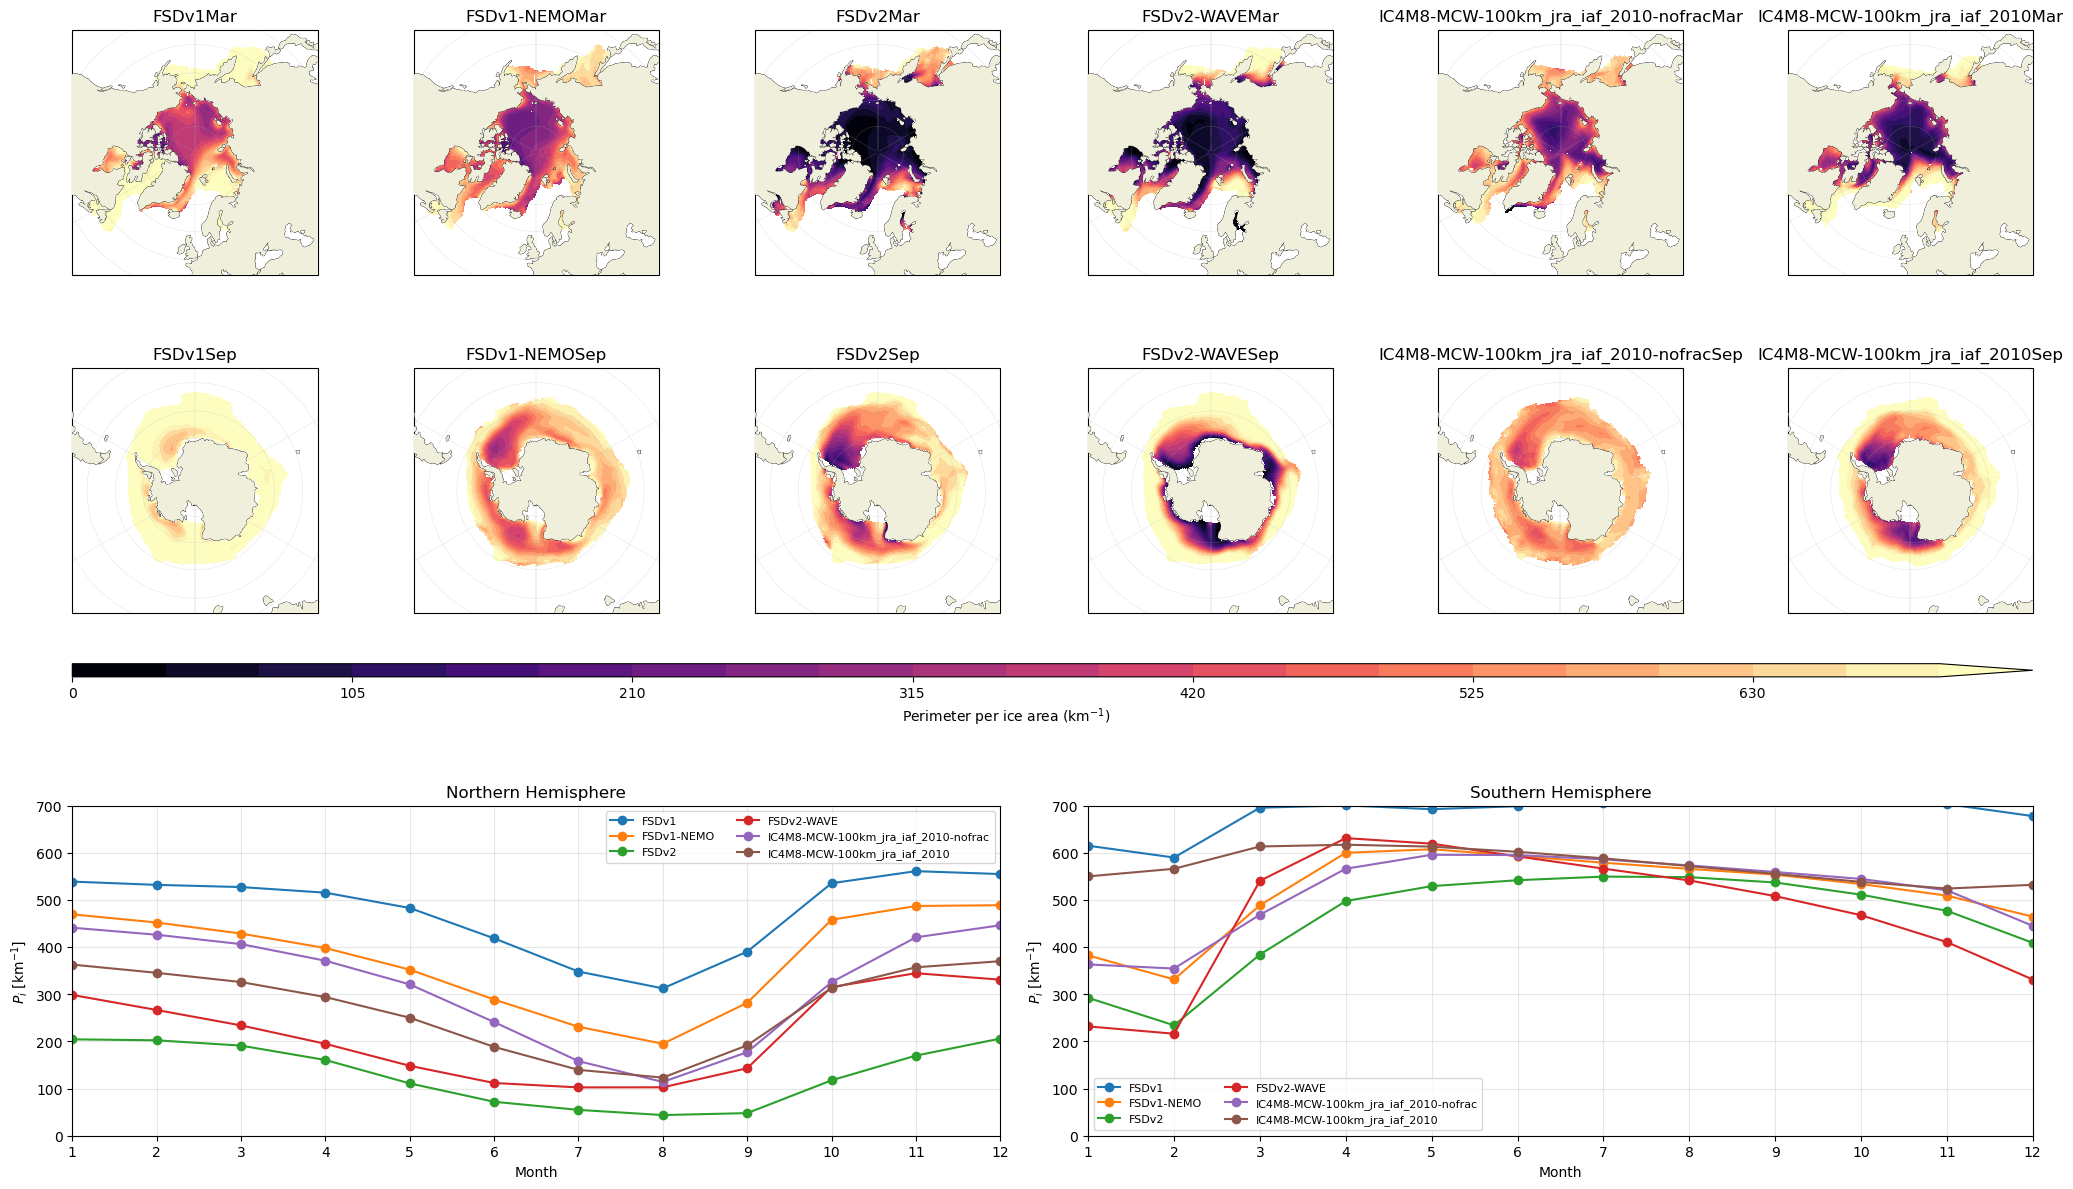

In [40]:
map_cases = [
    case for case in ["FSDv1", "FSDv1-NEMO", "FSDv2", "FSDv2-WAVE"]
    if case in roach_2019
]

plot_cases = (
    [(case, roach_2019[case]) for case in map_cases]
    + [(case, ds) for case, ds in om3_datasets.items()]
)

ncols = len(plot_cases)

fig = plt.figure(figsize=(3.0 * ncols, 12), constrained_layout=True)

gs = fig.add_gridspec(
    5, ncols,
    height_ratios=[
        1.0,   # north maps
        1.0,   # south maps
        0.04,  # thin colorbar row
        0.15,  # spacer row
        1.0,  # line plots
    ],
)

map_axes = []
mesh = None

for col, (case, ds) in enumerate(plot_cases):
    for row, (hemi, month) in enumerate([("north", 3), ("south", 9)]):
        ax = fig.add_subplot(
            gs[row, col],
            projection=ccrs.NorthPolarStereo() if hemi == "north" else ccrs.SouthPolarStereo(),
        )
        map_axes.append(ax)

        if "fsdperim" not in ds:
            ax.set_axis_off()
            continue

        da = ds["fsdperim"].where(ds["aice"] > min_ice_area_fraction)

        if da is None:
            ax.set_axis_off()
            continue

        da = monthly_mean(da, month)
        # da = subset_named_hemisphere(da, ds, hemi)
        if row == 0:
            plot_title = f"{case}\n{month_name(month)}"
        else:
            plot_title = f"{month_name(month)}"

        mesh = plot_map_panel(
            ax,
            da,
            ds,
            plot_title,
            cmap="magma",
            vmin=PERIMETER_LIMITS[0],
            vmax=PERIMETER_LIMITS[1],
            add_colorbar=False,
        )
        set_polar_extent(ax, hemi)

# Thin colorbar row spanning all columns.
if mesh is not None:
    cax = fig.add_subplot(gs[2, :])
    cbar = fig.colorbar(
        mesh,
        cax=cax,
        orientation="horizontal",
    )
    cbar.set_label("Perimeter per ice area (km$^{-1}$)")

split = ncols // 2

season_axes = {
    "north": fig.add_subplot(gs[4, :split]),
    "south": fig.add_subplot(gs[4, split:]),
}

for hemi, ax in season_axes.items():
    for case, ds in plot_cases:
        if "fsdperim" not in ds:
            continue

        da = ds["fsdperim"].where(ds["aice"] > min_ice_area_fraction)

        if da is None or "time" not in da.dims:
            continue

        fsdperim = (
            hemi_weighted_mean(da, ds, hemi)
            .groupby("time.month")
            .mean("time")
        )

        ax.plot(
            fsdperim.month,
            fsdperim.values,
            marker="o",
            label=case,
        )
    
    ax.set_xticks(range(1, 13))
    ax.set_xlim(1, 12)
    ax.set_ylim(0, 850)
    ax.set_ylabel("$P_i$ [km$^{-1}$]")
    ax.set_title("Northern Hemisphere" if hemi == "north" else "Southern Hemisphere")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    ax.set_xlabel("Month")

mkmd.savefig(f"Floe perimeter per unit sea ice area: maps and seasonal cycle", f"ACCESS-OM3 and Roach 2019.")

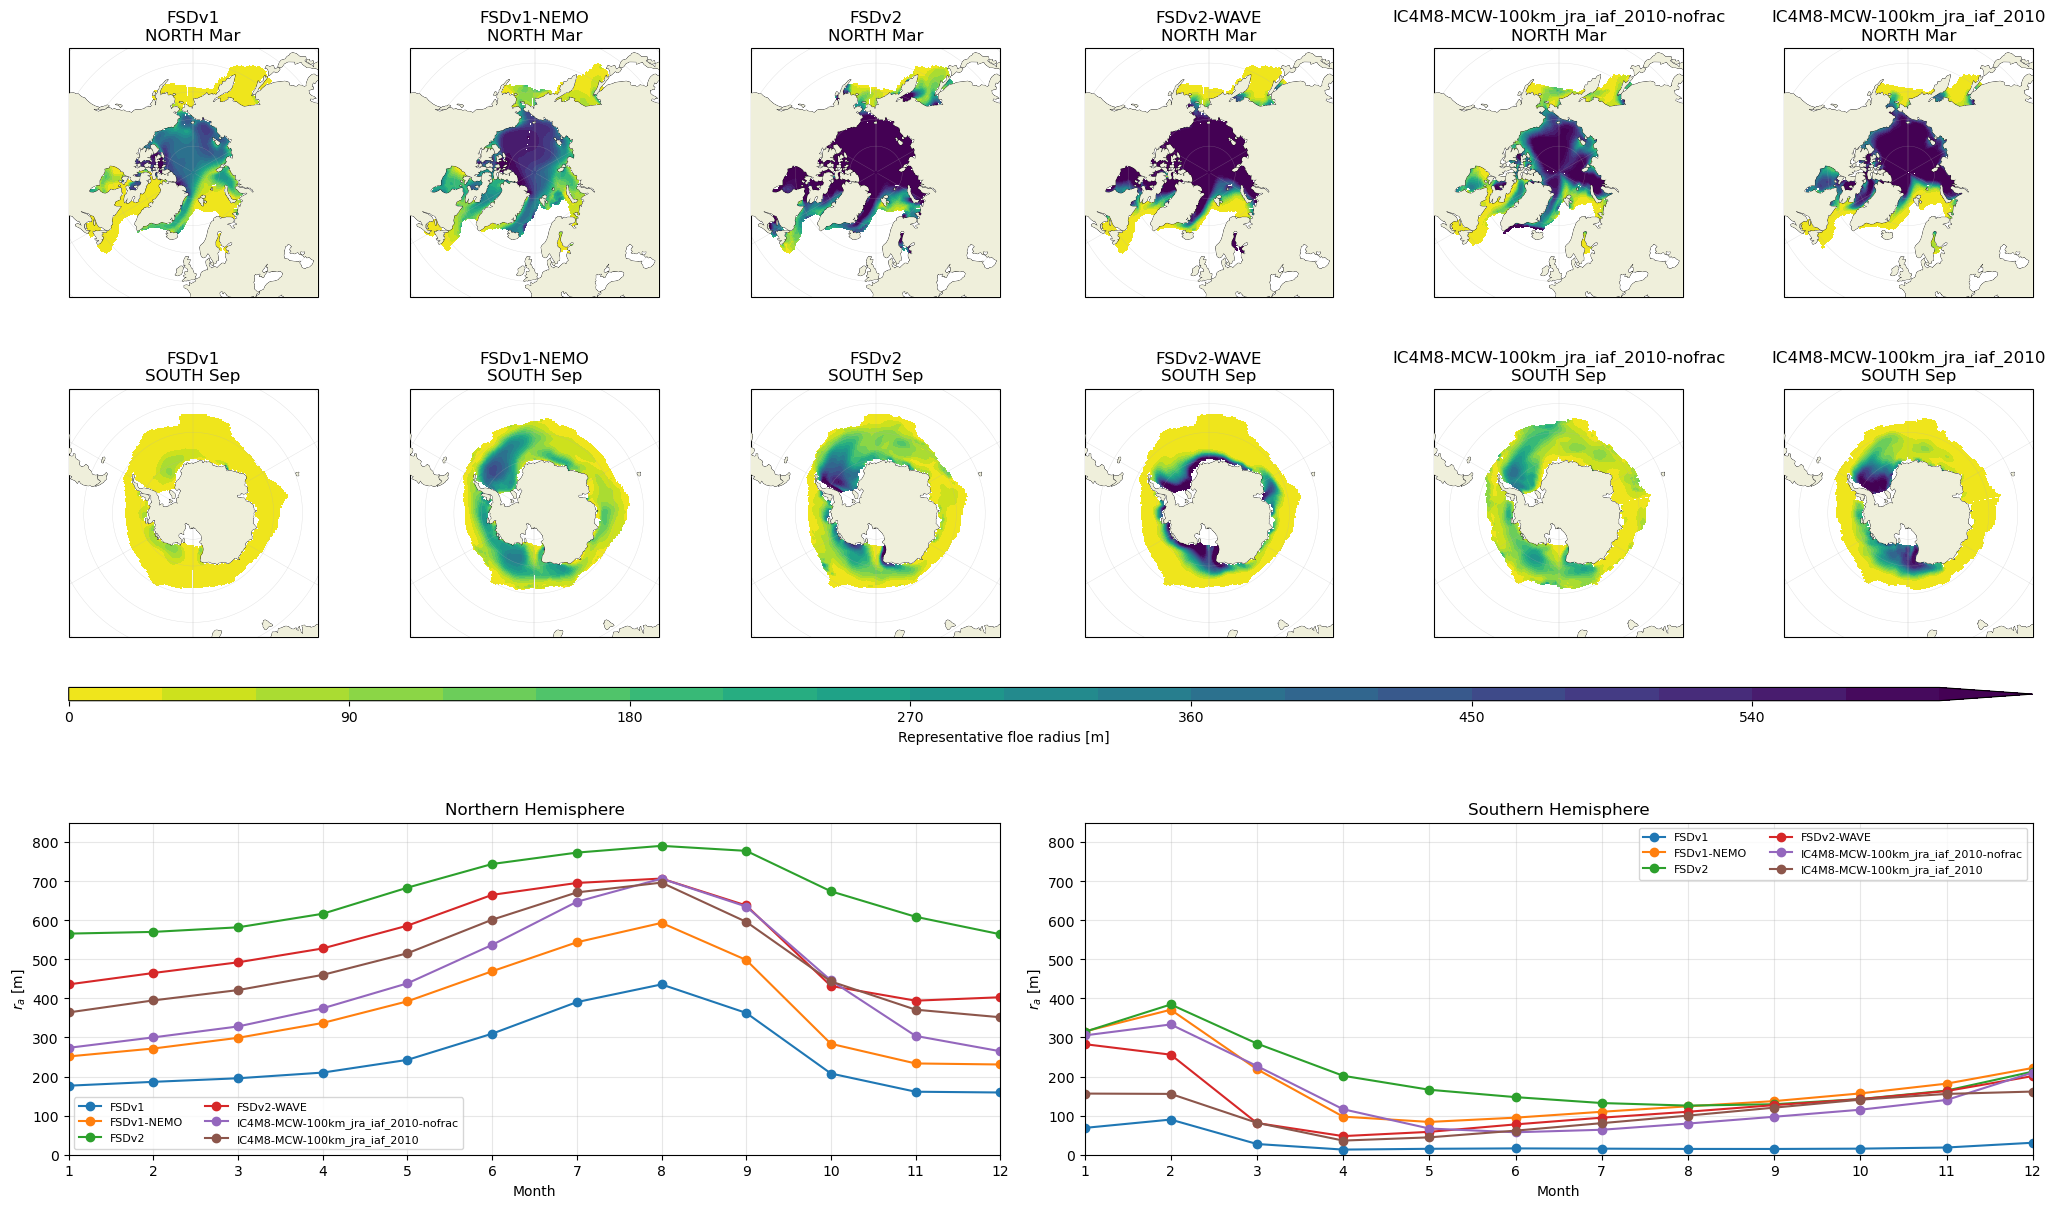

In [41]:
# Roach et al. 2019 Figure 2 analogue: representative floe radius with ACCESS-OM3 comparison.
rr_cases = [
    case for case in ["FSDv1", "FSDv1-NEMO", "FSDv2", "FSDv2-WAVE"]
    if case in roach_2019
]

plot_cases = (
    [(case, roach_2019[case]) for case in rr_cases]
    + [(case, ds) for case, ds in om3_datasets.items()]
)

ncols = len(plot_cases)

fig = plt.figure(figsize=(3.4 * ncols, 12), constrained_layout=True)

gs = fig.add_gridspec(
    5, ncols,
    height_ratios=[
        1.0,   # north maps
        1.0,   # south maps
        0.04,  # thin colorbar row
        0.15,  # spacer row
        1.0,  # line plots
    ],
)

map_axes = []
mesh = None

for col, (case, ds) in enumerate(plot_cases):
    for row, (hemi, month) in enumerate([("north", 3), ("south", 9)]):
        ax = fig.add_subplot(
            gs[row, col],
            projection=ccrs.NorthPolarStereo() if hemi == "north" else ccrs.SouthPolarStereo(),
        )
        map_axes.append(ax)

        if "fsdrad" not in ds:
            ax.set_axis_off()
            continue

        da = ds["fsdrad"].where(ds["aice"] > min_ice_area_fraction)

        if da is None:
            ax.set_axis_off()
            continue

        da = monthly_mean(da, month)
        # da = subset_named_hemisphere(da, ds, hemi)

        mesh = plot_map_panel(
            ax,
            da,
            ds,
            f"{case}\n{hemi.upper()} {month_name(month)}",
            cmap="viridis_r",
            vmin=REP_RADIUS_LIMITS[0],
            vmax=REP_RADIUS_LIMITS[1],
            add_colorbar=False,
        )
        set_polar_extent(ax, hemi)

# Thin colorbar row spanning all columns.
if mesh is not None:
    cax = fig.add_subplot(gs[2, :])
    cbar = fig.colorbar(
        mesh,
        cax=cax,
        orientation="horizontal",
    )
    cbar.set_label("Representative floe radius [m]")

split = ncols // 2

season_axes = {
    "north": fig.add_subplot(gs[4, :split]),
    "south": fig.add_subplot(gs[4, split:]),
}

for hemi, ax in season_axes.items():
    for case, ds in plot_cases:
        if "fsdrad" not in ds:
            continue

        da = ds["fsdrad"].where(ds["aice"] > min_ice_area_fraction)

        if da is None or "time" not in da.dims:
            continue

        fsdrad = (
            hemi_weighted_mean(da, ds, hemi)
            .groupby("time.month")
            .mean("time")
        )

        ax.plot(
            fsdrad.month,
            fsdrad.values,
            marker="o",
            label=case,
        )

    ax.set_xticks(range(1, 13))
    ax.set_xlim(1, 12)
    ax.set_ylim(0,850)
    ax.set_ylabel("$r_a$ [m]")
    ax.set_title("Northern Hemisphere" if hemi == "north" else "Southern Hemisphere")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    ax.set_xlabel("Month")

mkmd.savefig(f"Representative floe radii: maps and seasonal cycle", f"ACCESS-OM3 and Roach 2019.")

## Representative floe radius and floe size tendency seasonality
Roach et al. (2019) Figure 3

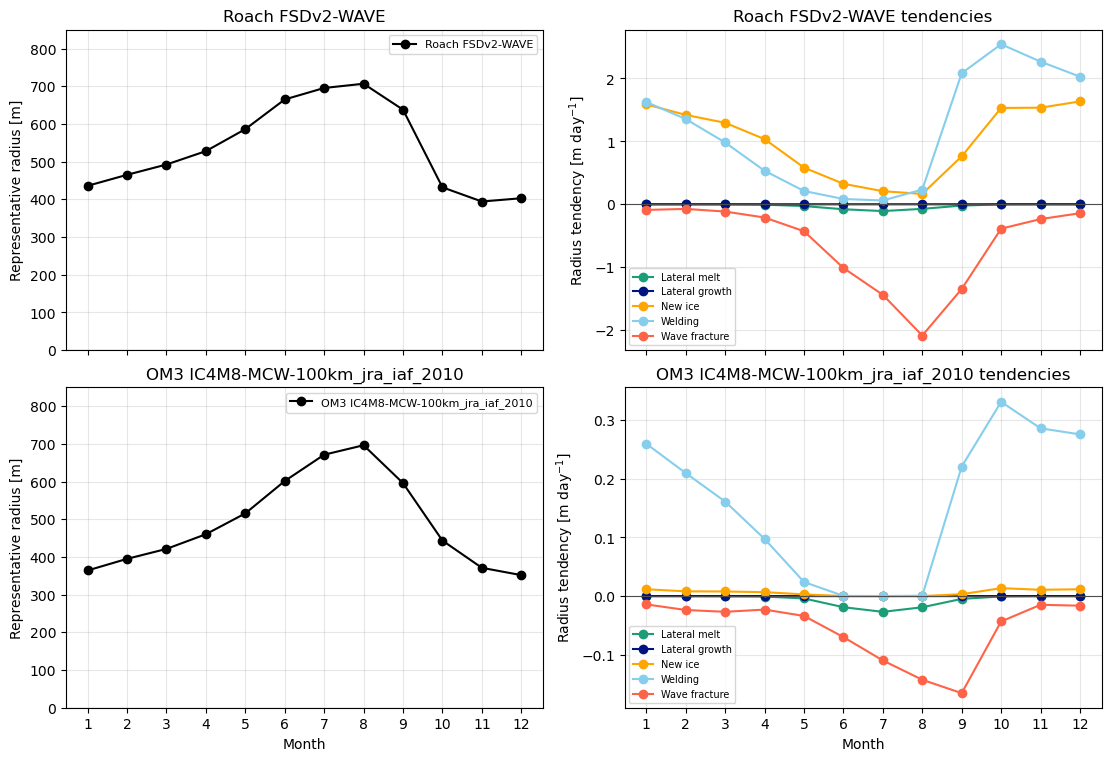

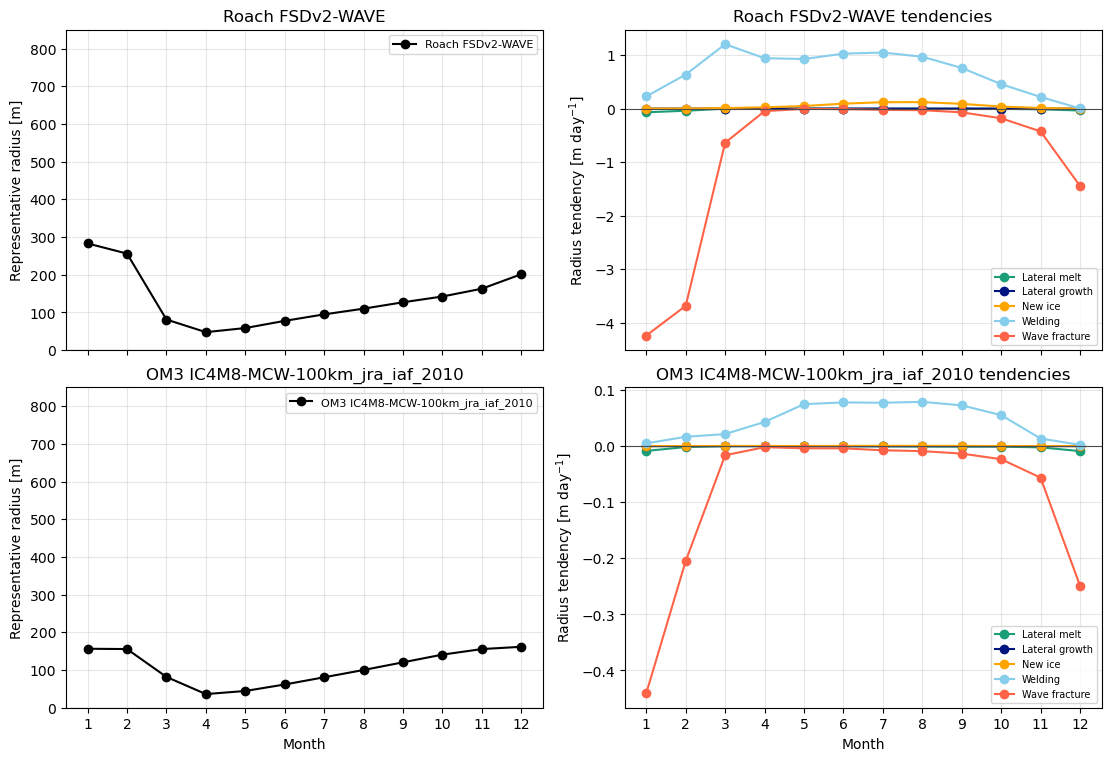

In [42]:
# Roach et al. 2019 Figure 3 analogue:
# Arctic representative radius and radius tendency seasonality.
hemi = "north"

radius_tendency_specs = [
    ("dafsd_latm_ra", "#1b9e77", "Lateral melt"),
    ("dafsd_latg_ra", "#001480", "Lateral growth"),
    ("dafsd_newi_ra", "#ffa500", "New ice"),
    ("dafsd_weld_ra", "#86ceeb", "Welding"),
    ("dafsd_wave_ra", "#ff6347", "Wave fracture"),
]


plot_cases = []

if "FSDv2-WAVE" in roach_2019:
    plot_cases.append(("Roach FSDv2-WAVE", roach_2019["FSDv2-WAVE"]))

if OM3_LABEL in om3_datasets:
    plot_cases.append((f"OM3 {OM3_LABEL}", om3_datasets[OM3_LABEL]))
else:
    plot_cases.append((f"OM3 {OM3_LABEL}", ds_om3))

for hemi in ["north", "south"]:
    fig, axes = plt.subplots(
        2, 2, figsize=(11, 7.5),
        sharex=True, constrained_layout=True,
    )
    
    for row, (case_label, ds) in enumerate(plot_cases[:2]):
        ice_mask = ds["aice"] > min_ice_area_fraction if "aice" in ds else True
    
        # Left column: representative radius.
        if "fsdrad" in ds:
            rr = ds["fsdrad"].where(ice_mask)
            cycle = hemi_weighted_mean(rr, ds, hemi).groupby("time.month").mean("time").load()
    
            axes[row,0].plot(
                cycle.month,
                cycle.values,
                marker="o", color='k',
                label=case_label,
            )
    
        # Right column: radius tendencies.
        for var_ra, color, label in radius_tendency_specs:
            if var_ra not in ds:
                continue
        
            radius_tend = (
                hemi_weighted_mean(ds[var_ra].where(ice_mask), ds, hemi)
                .groupby("time.month")
                .mean("time")
            )
        
            axes[row, 1].plot(
                radius_tend.month,
                radius_tend.values,
                marker="o",
                label=label,
                color=color,
            )
    
        axes[row, 0].set_title(case_label)
        axes[row, 0].set_ylabel("Representative radius [m]")
    
        axes[row, 1].set_title(f"{case_label} tendencies")
        axes[row, 1].set_ylabel("Radius tendency [m day$^{-1}$]")
    
    for ax in axes[0, :]:
        ax.set_xlabel("")

    for ax in axes[:,0]:
        ax.set_ylim(0, 850)
    
    for ax in axes[1, :]:
        ax.set_xlabel("Month")
    
    for ax in axes.flat:
        ax.set_xticks(range(1, 13))
        ax.grid(True, alpha=0.3)
        ax.axhline(0, color="0.3", lw=0.8)
    
    axes[0, 0].legend(fontsize=8)
    axes[0, 1].legend(fontsize=7, ncol=1)
    axes[1, 0].legend(fontsize=8)
    axes[1, 1].legend(fontsize=7, ncol=1)
    mkmd.savefig(f"Representative floe radius and floe size tendency seasonality {hemi}ern hemisphere", f"ACCESS-OM3 and Roach 2019.")

## Significant wave height maps

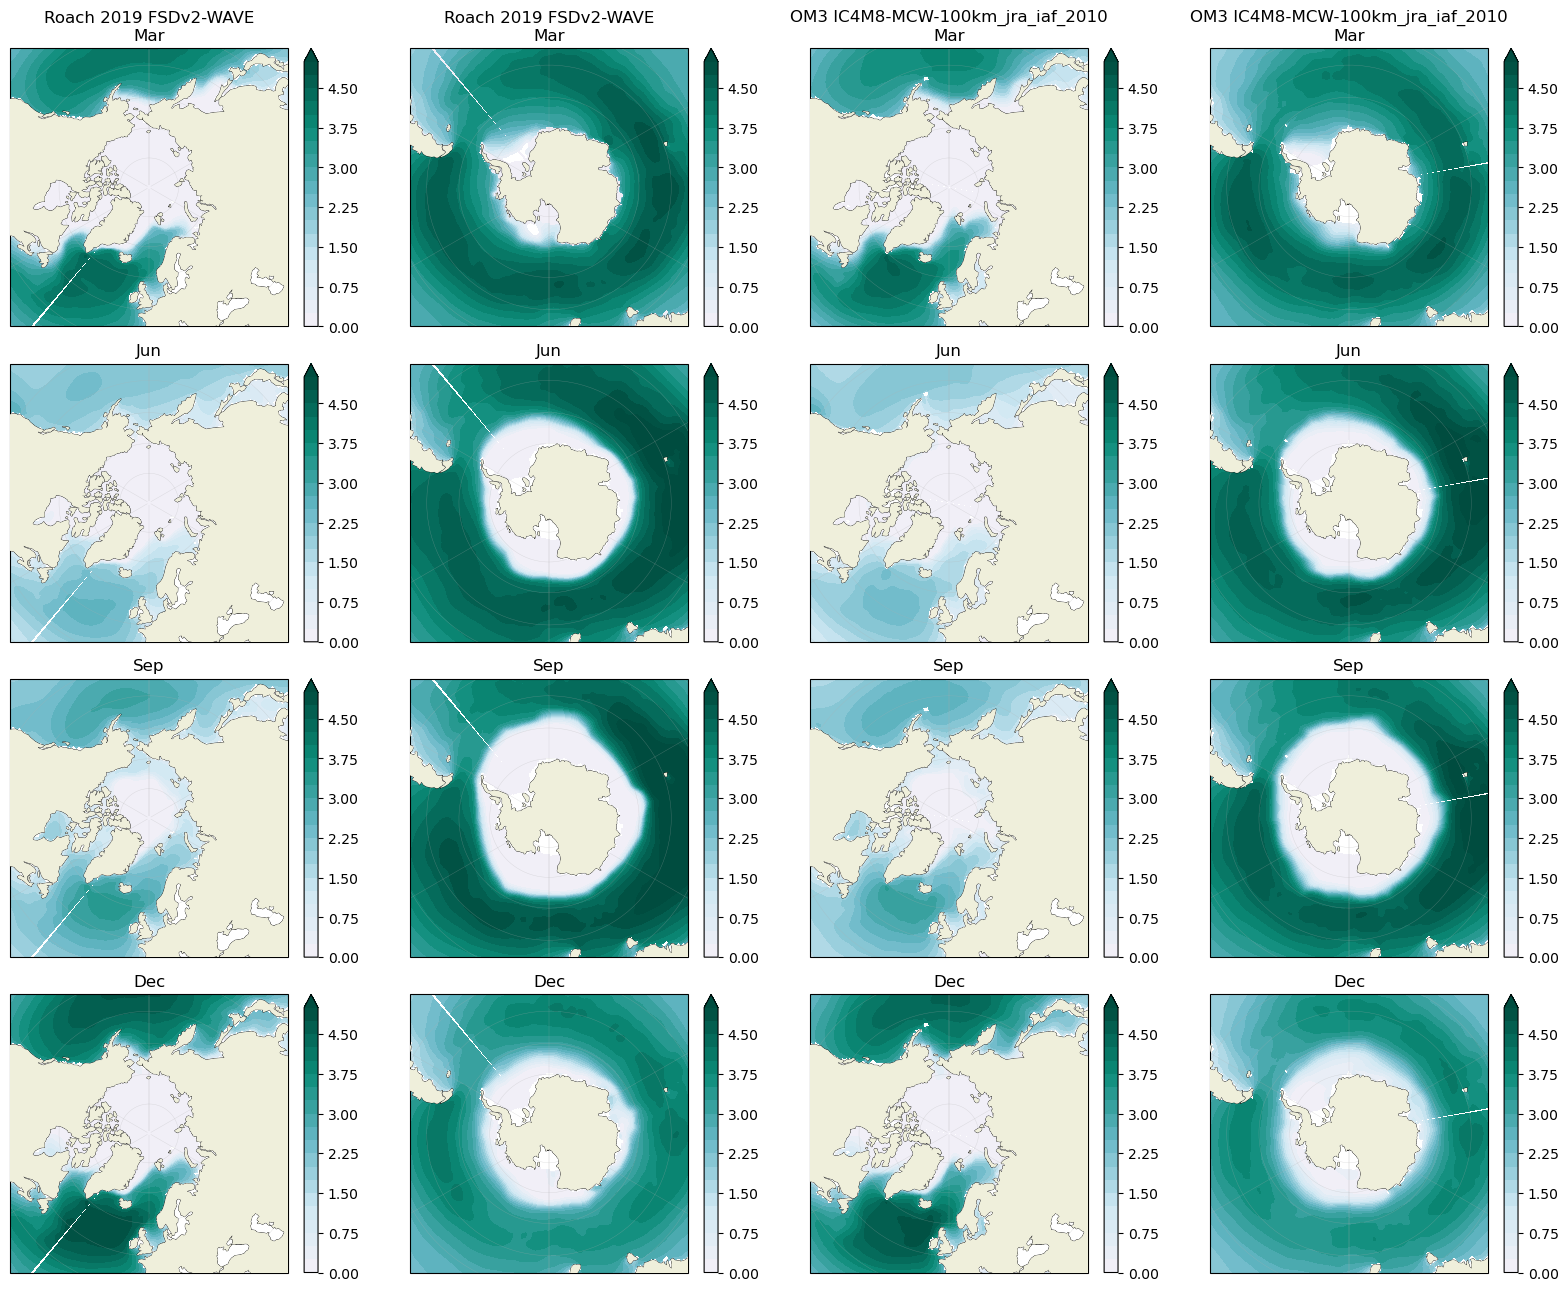

In [43]:
# Roach et al. 2019 Figure 4 analogue: significant wave height in ice.

WAVE_CMAP = LinearSegmentedColormap.from_list(
    "paper_wave",
    [
        "#f4f0f7",
        "#cfe8f3",
        "#67b7c7",
        "#0b8c78",
        "#004c3f",
    ],
)

def wave_height_var(ds):
    return var_if_present(
        ds,
        ["sigheight", "hs", "wave_significant_height", "significant_wave_height", "wave_sig_ht"],
    )


wave_cases = []

if wave_2019 is not None:
    hs_name = wave_height_var(wave_2019)
    if hs_name is not None:
        wave_cases.append(("Roach 2019 FSDv2-WAVE", wave_2019, hs_name))

if OM3_LABEL in om3_datasets:
    om3_hs_name = wave_height_var(om3_datasets[OM3_LABEL])
    if om3_hs_name is not None:
        wave_cases.append((f"OM3 {OM3_LABEL}", om3_datasets[OM3_LABEL], om3_hs_name))

map_months = [3, 6, 9, 12]
hemispheres = ["north", "south"]

nrows = len(map_months)
ncols = len(wave_cases) * len(hemispheres)

if wave_cases:
    fig = plt.figure(figsize=(4.0 * ncols, 3.2 * nrows), constrained_layout=True)

    for row, month in enumerate(map_months):
        for case_idx, (case_label, ds_wave, hs_name) in enumerate(wave_cases):
            for hemi_idx, hemi in enumerate(hemispheres):
                col = case_idx * len(hemispheres) + hemi_idx

                ax = polar_axis(
                    fig,
                    nrows,
                    ncols,
                    col + row * ncols + 1,
                    hemi,
                )

                da = mean_over_time_month(ds_wave[hs_name], month).squeeze(drop=True)
                if "time" in da.dims:
                    da = da.mean("time", skipna=True)
                if row == 0:
                    title = f"{case_label}\n{month_name(month)}"
                else:
                    title = f"{month_name(month)}"
                    
                plot_map_panel(ax, da, ds_wave, title, cmap=WAVE_CMAP, robust=False, vmin=0, vmax=5)
                set_polar_extent(ax, hemi)

    mkmd.savefig(f"Significant wave height maps", f"ACCESS-OM3 and Roach 2019.")

## Lateral melt hemispheric averages 

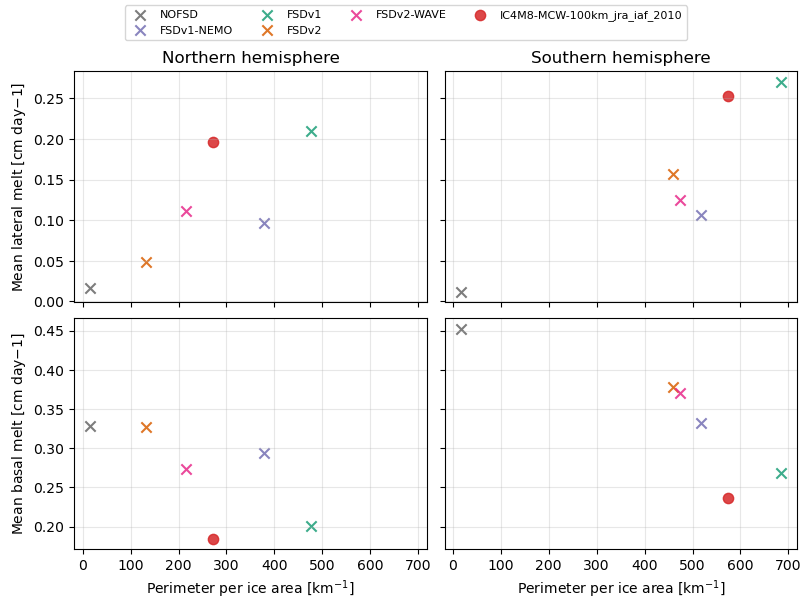

In [48]:
# Roach et al. 2019 Figure 5 analogue: annual lateral/basal melt against floe perimeter.
case_colors = {
    "NOFSD": "0.4",
    "FSDv1": "#1b9e77",
    "FSDv1-NEMO": "#7570b3",
    "FSDv2": "#d95f02",
    "FSDv2-WAVE": "#e7298a",
    # OM3 cases
    BASELINE_LABEL: "#e7298a",
    OM3_LABEL: "tab:red",
}

plot_cases = (
    [(case, ds, "x") for case, ds in roach_2019.items()]
    + [(case, ds, "o") for case, ds in om3_datasets.items()]
)

hemispheres = ["north", "south"]
melt_vars = [("meltl", "lateral melt"), ("meltb", "basal melt")]

fig, axes = plt.subplots(
    len(melt_vars),
    len(hemispheres),
    figsize=(8, 6.0),
    constrained_layout=True,
    sharex=True,
    sharey="row",
)

for col, hemi in enumerate(hemispheres):
    for case, ds, marker in plot_cases:
        if "fsdperim" not in ds or "aice" not in ds:
            continue

        ice_mask = ds["aice"] > min_ice_area_fraction 
        perim = ds["fsdperim"].where(ice_mask)
        p = hemi_weighted_mean(perim, ds, hemi).mean("time").load()

        if not np.isfinite(float(p)):
            print(case)
            continue

        for row, (melt_name, melt_label) in enumerate(melt_vars):
            ax = axes[row, col]

            if melt_name not in ds:
                continue

            melt_da = ds[melt_name].where(ice_mask)
            melt = hemi_weighted_mean(melt_da, ds, hemi).mean("time").load()

            if not np.isfinite(float(melt)):
                continue

            ax.scatter(
                float(p), float(melt),
                label=case, marker=marker,
                color=case_colors.get(case, "0.3"),
                s=55, alpha=0.85,
            )

    axes[0, col].set_title(f"{hemi.title()}ern hemisphere")

for row, (_, melt_label) in enumerate(melt_vars):
    for col, hemi in enumerate(hemispheres):
        ax = axes[row, col]
        axes[1, col].set_xlabel("Perimeter per ice area [km$^{-1}$]")
        ax.grid(True, alpha=0.3)
    axes[row, 0].set_ylabel(rf"Mean {melt_label} [cm day${-1}$]")
    axes[row, 1].set_ylabel("")

# Deduplicate legend entries.
handles, labels = axes[0, 1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="outside upper center",
    ncol=4,
    fontsize=8,
)

mkmd.savefig(f"Lateral melt hemispheric averages ", f"ACCESS-OM3 and Roach 2019.")

### Sea ice concentration difference maps

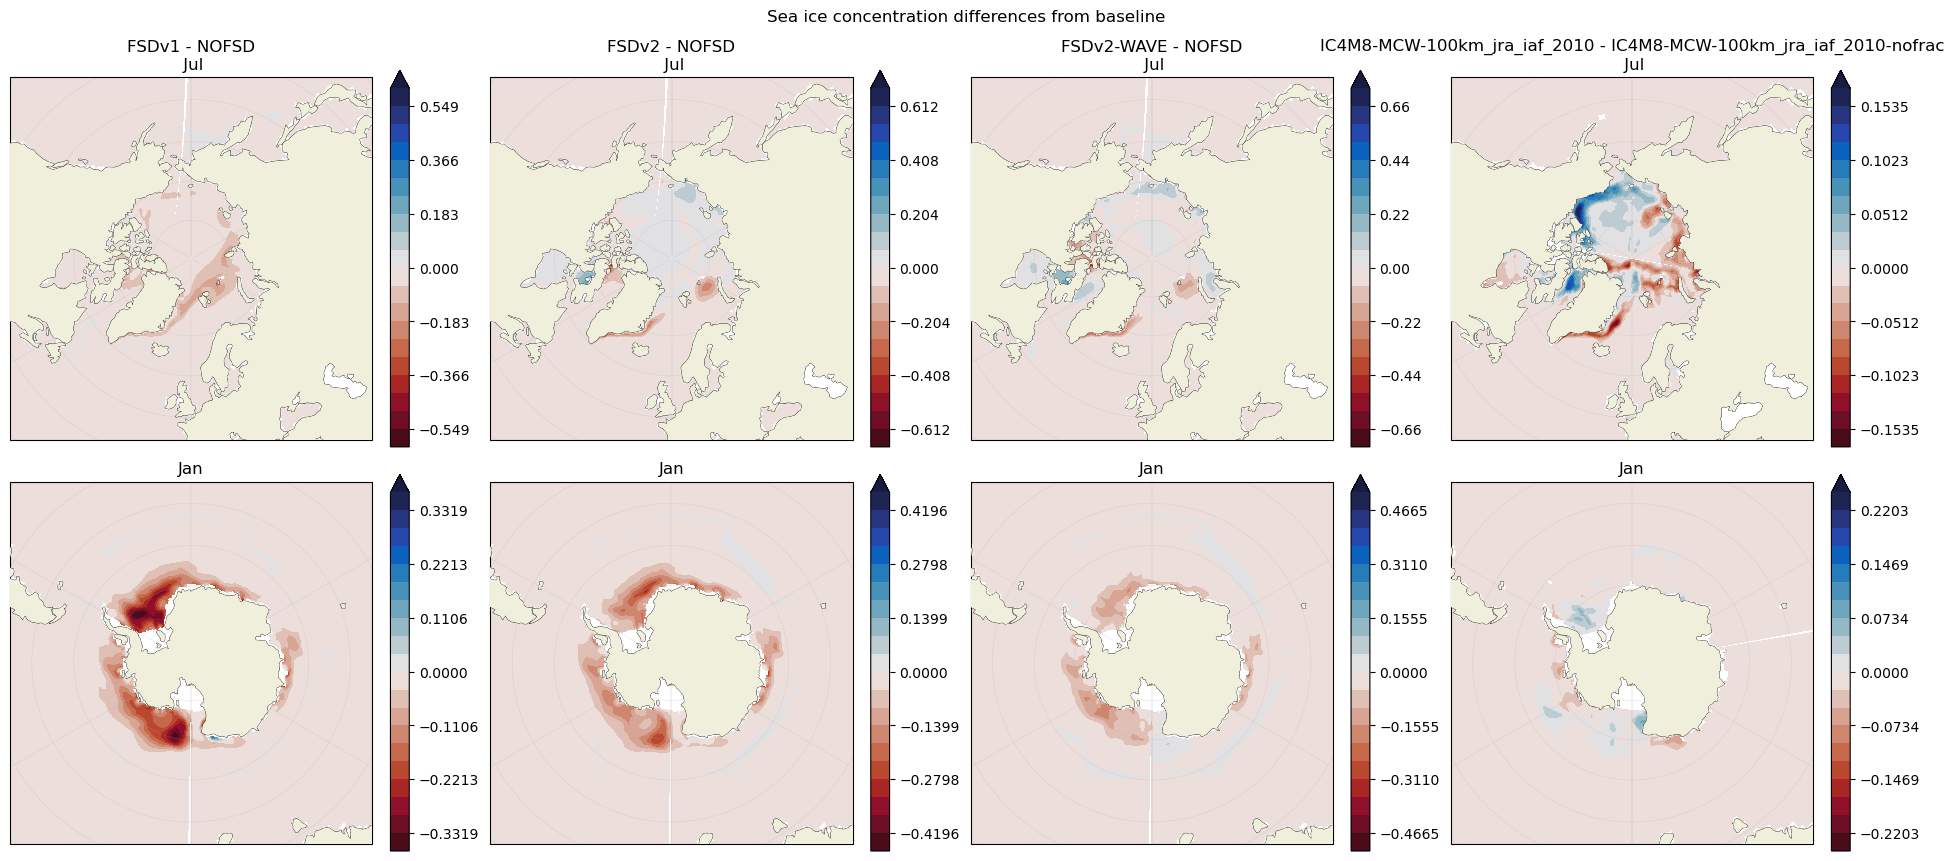

In [49]:
# Roach et al. 2019 Figure 6 analogue: sea ice concentration differences from baseline.

roach_diff_cases = []
if "NOFSD" in roach_2019:
    roach_diff_cases = [
        (case, roach_2019[case], roach_2019["NOFSD"], f"{case} - NOFSD")
        for case in ["FSDv1", "FSDv2", "FSDv2-WAVE"]
        if case in roach_2019
    ]

om3_diff_cases = []
if BASELINE_LABEL in om3_datasets:
    om3_diff_cases = [
        (case, ds, om3_datasets[BASELINE_LABEL], f"{case} - {BASELINE_LABEL}")
        for case, ds in om3_datasets.items()
        if case != BASELINE_LABEL
    ]

diff_cases = roach_diff_cases + om3_diff_cases

fig = plt.figure(figsize=(4.8 * len(diff_cases), 8.5), constrained_layout=True)

for col, (case, ds, base_ds, title_label) in enumerate(diff_cases, start=1):
    for row, (hemi, month) in enumerate([("north", 7), ("south", 1)]):
        ax = polar_axis(fig, 2, len(diff_cases), col + row * len(diff_cases), hemi)

        if "aice" not in ds or "aice" not in base_ds:
            ax.set_axis_off()
            continue

        base = mean_over_time_month(base_ds["aice"], month)
        exp = mean_over_time_month(ds["aice"], month)
        diff = (exp - base).load()
        lim = float(np.nanmax(np.abs(diff.values)))

        if row == 0:
            plot_title = f"{title_label}\n {month_name(month)}"
        else:
            plot_title = f"{month_name(month)}"
            
        plot_map_panel(
            ax,
            diff,
            ds,
            plot_title,
            cmap=BALANCE_CMAP_R,
            vmin=-lim,
            vmax=lim,
        )
        set_polar_extent(ax, hemi)

fig.suptitle("Sea ice concentration differences from baseline")
mkmd.savefig(f"Sea ice concentration difference maps ", f"ACCESS-OM3 and Roach 2019.")

In [ ]:
client.close()